In [65]:
global_v_offset = 1.212 # 875this is 100% wrong
global_v_scaling = 1 # -0.003 # or -1 ?
# like i remember the guy telling me we should multiply by -0.003 but i could be wrong

Linear fit coefficients:
Slope: 1.192184e+00
Intercept: 1.212277


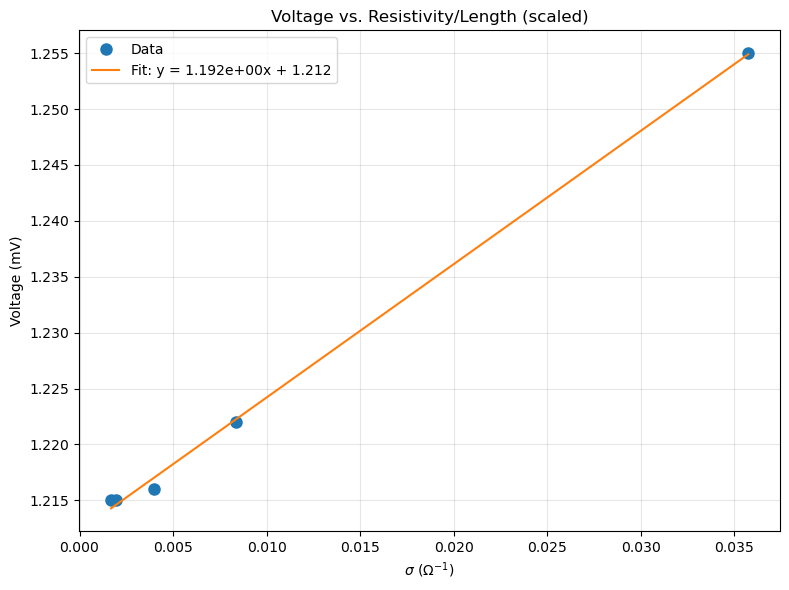

R²: 0.9985


In [66]:
# Task 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as p

# import csv - note: CSV has spaces after commas, need to handle
data = pd.read_csv('data1.csv', skipinitialspace=True)

# plot the data
# Convert units: res is in ohm*cm, l is in micrometers
# Calculate res/l in units of ohm
# res/l = (ohm*cm) / (micrometer) = (ohm*cm) / (10^-4 cm) = 10^4 ohm
data['res_over_l'] = data['res'] / data['l'] * 1e4
data['l_over_res'] = 1 / data['res_over_l']

# Scale voltages
v_scaled = data['v'] 

# Perform linear fit
coeffs = np.polyfit(data['l_over_res'], v_scaled, 1)
slope = coeffs[0]
intercept = coeffs[1]

# Print coefficients
print(f"Linear fit coefficients:")
print(f"Slope: {slope:.6e}")
print(f"Intercept: {intercept:.6f}")

# Plot voltage vs res/l
p.figure(figsize=(8, 6))
p.plot(data['l_over_res'], v_scaled, 'o', markersize=8, label='Data')
# Plot fit line
x_fit = np.linspace(data['l_over_res'].min(), data['l_over_res'].max(), 100)
y_fit = slope * x_fit + intercept
p.plot(x_fit, y_fit, '-', label=f'Fit: y = {slope:.3e}x + {intercept:.3f}')
p.xlabel(r'$\sigma$ ($\Omega^{-1}$)')
p.ylabel('Voltage (mV)')
p.title('Voltage vs. Resistivity/Length (scaled)')
p.legend()
p.grid(True, alpha=0.3)
p.tight_layout()
p.show()

# Print R² and define conductance_from_voltage function using fit values from previous cell
y_pred = slope * data['l_over_res'] + intercept
ss_res = np.sum((v_scaled - y_pred) ** 2)
ss_tot = np.sum((v_scaled - np.mean(v_scaled)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
print(f"R²: {r2:.4f}")

def conductance_from_voltage(voltage, slope=slope, intercept=intercept):
    """Calculate conductance (l_over_res) from voltage using fit parameters."""
    return (voltage - intercept) / slope
    # return (voltage - intercept) / slope # GGG

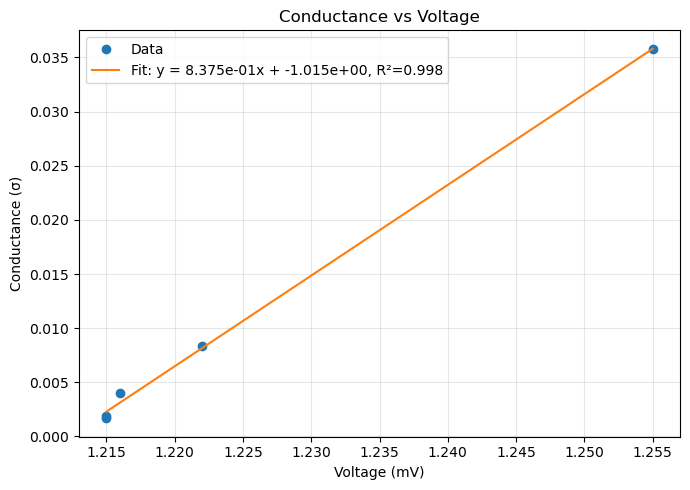

Fit slope: 8.375368e-01
Fit intercept: -1.015311e+00
R²: 0.9985


In [67]:
# Plot conductance (sigma) as a function of v from data1.csv, with linear fit and print fit params and R²
# data = pd.read_csv('data1.csv', skipinitialspace=True)

x = data['v']
y = data['l_over_res']
fit_coeffs = np.polyfit(x, y, 1)
fit_slope, fit_intercept = fit_coeffs
fit_y = fit_slope * x + fit_intercept
ss_res = np.sum((y - fit_y) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(x, y, 'o', label='Data')
plt.plot(x, fit_y, '-', label=f'Fit: y = {fit_slope:.3e}x + {fit_intercept:.3e}, R²={r2:.3f}')
plt.xlabel('Voltage (mV)')
plt.ylabel('Conductance (σ)')
plt.title('Conductance vs Voltage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Fit slope: {fit_slope:.6e}')
print(f'Fit intercept: {fit_intercept:.6e}')
print(f'R²: {r2:.4f}')

In [68]:
import pandas as pd
import numpy as np

def analyze_calibration(file_path):
    # Load Data
    data = pd.read_csv(file_path, skipinitialspace=True)
    
    # Calculate Sheet Conductance (Sigma_s) in Siemens
    # Formula: Sigma = (Thickness_um * 1e-4) / Resistivity_OhmCm
    data['sigma_s'] = (data['l'] * 1e-4) / data['res']
    
    # Perform Linear Fit: sigma_s = slope * V + intercept
    slope, intercept = np.polyfit(data['v'], data['sigma_s'], 1)
    
    # Calculate physical offset (Voltage at zero conductance)
    v_offset = -intercept / slope
    
    return slope, intercept, v_offset

# --- Usage ---
slope, intercept, v_offset = analyze_calibration('data1.csv')

print(f"Fit Parameters derived from data1.csv:")
print(f"  Slope     = {slope:.4f} S/V")
print(f"  Intercept = {intercept:.4f} S")
print(f"  V_offset  = {v_offset:.4f} V (Baseline Voltage)")

def conductance_from_voltage(voltage):
    """
    Calculates sheet conductance from voltage using the linear fit from data1.csv.
    
    Note: The fit from 'data1.csv' yields a POSITIVE slope. 
    If your transient signal logic requires a negative relationship (decaying signal),
    you must manually override the slope here (e.g., set slope = -0.003).
    """
    # Using the fitted parameters:
    # sigma = 0.8375 * V - 1.0153
    # Or physically: sigma = 0.8375 * (V - 1.2123)
    
    sigma = 0.8375 * voltage - 1.0153
    
    return sigma

Fit Parameters derived from data1.csv:
  Slope     = 0.8375 S/V
  Intercept = -1.0153 S
  V_offset  = 1.2123 V (Baseline Voltage)


originally we had measured the voltage offset to be 1.225V (the dc level). however this didnt give great results. the way we determined the v_offset was by the numerical fit

In [69]:
# Calculate conductance and d for task7.csv and save result
import pandas as pd

task7 = pd.read_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv')
task7['conductance'] = conductance_from_voltage(task7['v'] )  # scale voltage
# task7['conductance'] = conductance_from_voltage((task7['v'] - global_v_offset)*global_v_scaling )  # scale voltage GGG
task7['d'] = task7['conductance'] * task7['res']
task7.to_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv', index=False)
task7

,i,v,res,conductance,d
0,D030,1.232,21.000,0.016500,0.346500
1,V42,1.326,4.320,0.095225,0.411372
2,ing1,1.382,3.018,0.142125,0.428933
3,china,1.574,1.000,0.302925,0.302925
4,l1_p,1.639,0.685,0.357363,0.244793
5,S9,1.753,0.370,0.452837,0.167550
6,feri,1.882,0.147,0.560875,0.082449


Slope: -0.69947
Intercept: 1.39666
R^2: 0.99862


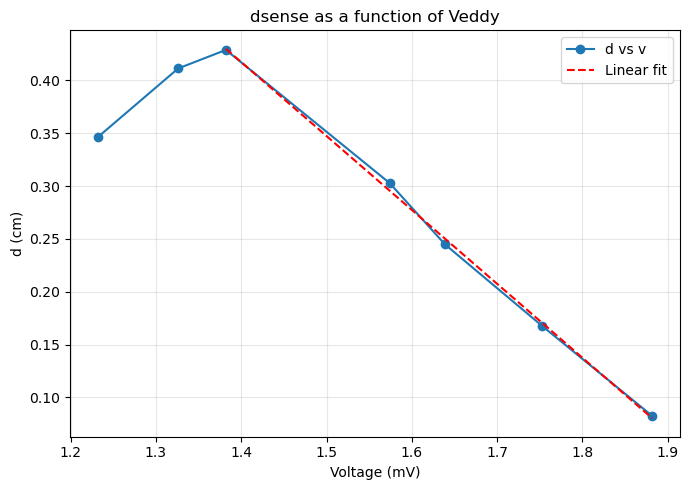

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

# Reload and sort
task7_sorted = pd.read_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv').sort_values('v')
task7_sorted.to_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv', index=False)

# Exclude the first two points
v_fit = task7_sorted['v'].iloc[2:]
d_fit = task7_sorted['d'].iloc[2:]

# Fit a first-order polynomial
coeffs = np.polyfit(v_fit, d_fit, 1)
fit_fn = np.poly1d(coeffs)

# Calculate R^2
d_pred = fit_fn(v_fit)
r2 = r2_score(d_fit, d_pred)

# Print slope, intercept, and R^2
print(f"Slope: {coeffs[0]:.5f}")
print(f"Intercept: {coeffs[1]:.5f}")
print(f"R^2: {r2:.5f}")

# Plot
plt.figure(figsize=(7,5))
plt.plot(task7_sorted['v'], task7_sorted['d'], 'o-', label='d vs v')
plt.plot(v_fit, d_pred, 'r--', label='Linear fit')
plt.xlabel('Voltage (mV)')
plt.ylabel('d (cm)')
plt.title('dsense as a function of Veddy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

it says to fit a suitable function but wtf
maybe we can say that it is linear, but below a certain point, then it is not properly measured
@petya

i remember the lab instructor saying to scale by -0.003 when doing > task9

but then i got better results by using -3

it's kinda weird but i think it converts the voltage consiedring the amplification of the device

like i think the previous measurements gave you the Veddy and these ones (with time series .trn data) give you some shit. idk. but if i dont scale by a negative number i get non-sensical results.

In [71]:
# global_v_scaling = -0.003
global_v_scaling = -3
# global_v_scaling = 1

In [72]:
import numpy as np

def get_noise_parameters(filepath):
    """
    Reads a 'noise-only' .trn file to determine the system's noise floor.
    Returns the standard deviation (sigma) of the signal.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    # Find data start (same logic as your reader)
    data_start = None
    for i, line in enumerate(lines):
        try:
            parts = line.strip().split()
            if len(parts) == 2:
                float(parts[0]); float(parts[1])
                data_start = i
                break
        except ValueError:
            continue
            
    if data_start is None:
        raise ValueError("No data found in noise file.")

    # Load data
    data = np.loadtxt(lines[data_start:])
    
    # We are interested in the variation (Standard Deviation)
    # This captures the "thickness" of the noise band
    voltage_raw = data[:, 1]
    noise_std = np.std(voltage_raw)
    
    print(f"--- Noise Analysis for {filepath} ---")
    print(f"Mean Level: {np.mean(voltage_raw):.6f}")
    print(f"Noise Std Dev (sigma): {noise_std:.6f}")
    print(f"Recommended Threshold (3*sigma): {3 * noise_std:.6f}")
    
    return noise_std

# --- Usage ---
# Replace with your actual path string
noise_file_path = r'gregorio-jaca-peter-tallosy_ePCD\dc-level.trn'
SYSTEM_NOISE_STD = get_noise_parameters(noise_file_path)

--- Noise Analysis for gregorio-jaca-peter-tallosy_ePCD\dc-level.trn ---
Mean Level: 875.041925
Noise Std Dev (sigma): 1.002305
Recommended Threshold (3*sigma): 3.006915


In [73]:
import numpy as np

def read_trn_file(filepath, noise_std=SYSTEM_NOISE_STD, snr_threshold=3.0, buffer_points=60):
    """
    Reads a TRN file and truncates the tail when the signal decays into the noise floor.
    
    Parameters:
    -----------
    filepath : str
        Path to the .trn file.
    noise_std : float
        The standard deviation of the system noise (raw voltage units).
    snr_threshold : float
        Cutoff threshold in multiples of sigma (default 3.0).
    buffer_points : int
        Number of extra points to keep after the threshold is crossed.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Find where the data starts
    data_start = None
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) == 2:
            try:
                float(parts[0])
                float(parts[1])
                data_start = i
                break
            except ValueError:
                continue
                
    if data_start is None:
        raise ValueError(f"No data found in {filepath}")

    # Read data
    data = np.loadtxt(lines[data_start:])
    times = data[:, 0]
    raw_voltage = data[:, 1]
    
    # Calculate values as per your requirement (relative to start)
    # Note: global_v_scaling must be defined in your scope or passed in
    values = (raw_voltage - raw_voltage[0]) * global_v_scaling

    # --- Truncation Logic ---
    if noise_std is not None:
        # 1. Estimate the Baseline (Equilibrium) from the tail
        # We assume the last 10% of points are the 'dead' baseline
        tail_len = max(5, int(len(raw_voltage) * 0.1))
        baseline_voltage = np.mean(raw_voltage[-tail_len:])
        
        # 2. Calculate the "Signal Above Baseline"
        # This describes how far the current voltage is from the noise floor
        signal_from_floor = np.abs(raw_voltage - baseline_voltage)
        
        # 3. Determine the absolute noise threshold
        # noise_std is in raw voltage units, so we compare directly to raw voltage difference
        noise_limit_raw = noise_std * snr_threshold
        
        # 4. Find where the signal is still significant
        # We look for indices where the signal is stronger than the noise
        useful_indices = np.where(signal_from_floor > noise_limit_raw)[0]
        
        if len(useful_indices) > 0:
            last_useful_idx = useful_indices[-1]
            
            # 5. Apply Buffer and Slice
            cut_idx = min(last_useful_idx + buffer_points, len(values))
            
            # Update the arrays
            times = times[:cut_idx]
            values = values[:cut_idx]
            
            # Optional: Print debug info to see it working
            # print(f"Cutting at index {cut_idx}/{len(data)} (Time: {times[-1]:.2e}s)")

    return times, values

In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

# def read_trn_file(filepath):
#     with open(filepath, 'r') as f:
#         lines = f.readlines()
#     # Find where the data starts (first line with two numbers)
#     data_start = None
#     for i, line in enumerate(lines):
#         parts = line.strip().split()
#         if len(parts) == 2:
#             try:
#                 float(parts[0])
#                 float(parts[1])
#                 data_start = i
#                 break
#             except ValueError:
#                 continue
#     if data_start is None:
#         raise ValueError(f"No data found in {filepath}")
#     # Read data
#     data = np.loadtxt(lines[data_start:])
#     times = data[:, 0]
#     values = (data[:, 1]-data[:, 1][0])*global_v_scaling # GGG
#     return times, values

def plot_trn_file(filepath, label=None):
    times, values = read_trn_file(filepath)
    plt.plot(times, values, label=label or os.path.basename(filepath))
    # plt.plot(times[1000:], values[1000:], label=label or os.path.basename(filepath))

    # plt.xlabel('Time (us)')
    # plt.ylabel('Signal (mV)')
    # plt.title('uPCD Transient Files')
    # plt.legend()
    # plt.show()

def plot_trn_directory(directory):
    trn_files = glob(os.path.join(directory, '*.trn'))
    plt.figure(figsize=(10, 6))
    for f in trn_files:
        plot_trn_file(f)
    plt.xlabel('Time (us)')
    plt.ylabel('Signal (mV)')
    plt.title('uPCD Transient Files')
    plt.legend()
    plt.show()

def analyze_trn_file(filepath):
    times, values = read_trn_file(filepath)
    values = values[500:]
    stats = {
        'mean': np.mean(values),
        'std': np.std(values),
        'min': np.min(values),
        'max': np.max(values),
        'median': np.median(values),
        'rms': np.sqrt(np.mean(values**2)),
        'n_points': len(values)
    }
    
    return stats

# Example usage:
# plot_trn_file('gregorio-jaca-peter-tallosy_ePCD/dc-level.trn')
# plot_trn_directory('gregorio-jaca-peter-tallosy_ePCD/first')
# stats = analyze_trn_file('gregorio-jaca-peter-tallosy_ePCD/dc-level.trn')
# print(stats)


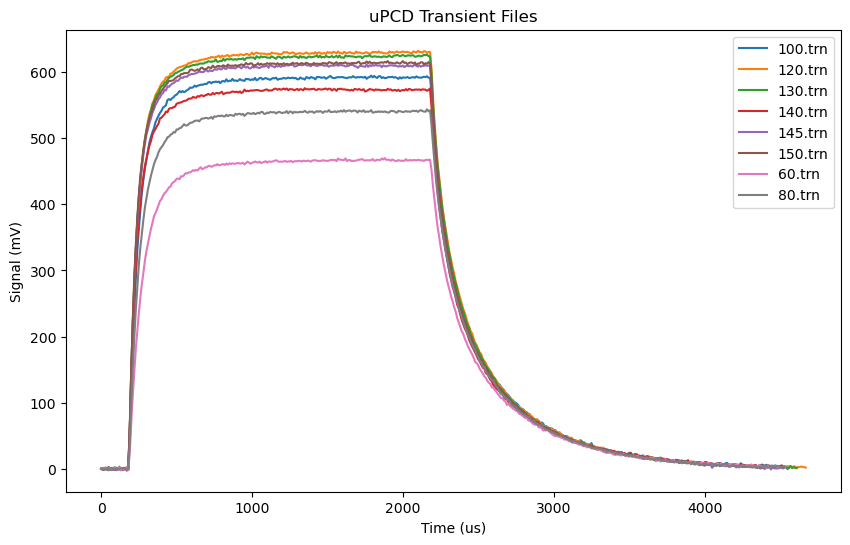

{'mean': -0.18773778920307396, 'std': 3.069408059147461, 'min': -12.509999999999877, 'max': 10.290000000000191, 'median': 0.0, 'rms': 3.0751441122416106, 'n_points': 1167}


In [75]:
# plot_trn_file('gregorio-jaca-peter-tallosy_ePCD/first/60.trn')
plot_trn_directory('gregorio-jaca-peter-tallosy_ePCD/first')
stats = analyze_trn_file('gregorio-jaca-peter-tallosy_ePCD/dc-level.trn')
print(stats)

In [76]:
import re
from scipy.optimize import curve_fit, minimize_scalar
from scipy.stats import linregress

def parse_trn_header(filepath):
    """Parse header for units and metadata."""
    header = {}
    with open(filepath, 'r') as f:
        for line in f:
            if re.match(r'^\d+\s', line):
                break
            if ':' in line:
                key, val = line.split(':', 1)
                header[key.strip()] = val.strip()
    # Extract units
    time_unit = 'us'
    voltage_unit = 'mV'
    for k, v in header.items():
        if 'Timebase' in k and 'us' in v:
            time_unit = 'us'
        if 'Delta' in k and 'ns' in v:
            time_unit = 'ns'
        if 'Amplitude' in k and 'mV' in v:
            voltage_unit = 'mV'
    return header, time_unit, voltage_unit



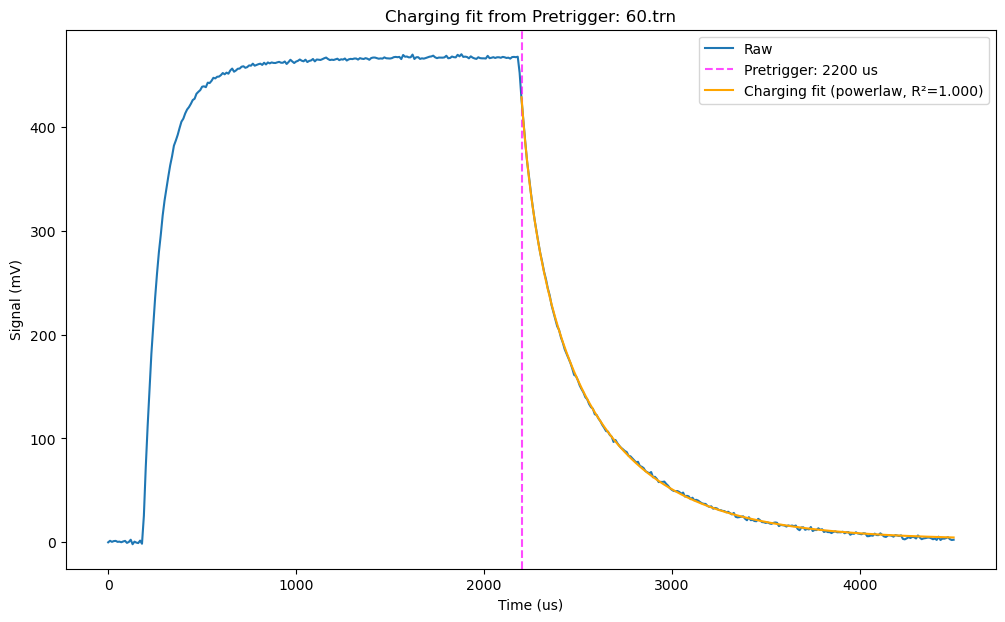

Fit parameters: A=426.155, tau=553.190, t0=68.506, n=0.283, O=2.220
R²: 0.9998


In [77]:
# Fit charging region from Pretrigger to end, plot and show R²
import re
from scipy.optimize import curve_fit

def charging_func_exp(t, A, tau, C):
    """Simple exponential charging: A * (1 - exp(-t/tau)) + C"""
    return A * (np.exp(-t / tau)) + C

def charging_func_powerlaw(t, A, tau, t0, n, O):
    """Power-law charging: A * exp(-t/tau) / (1 + t/t0)**n + O"""
    return A * (np.exp(-t / tau)) / ((1 + (t / t0))**n) + O

def fit_charging_from_pretrigger(filepath, model='powerlaw'):
    times, values = read_trn_file(filepath)
    header, time_unit, voltage_unit = parse_trn_header(filepath)
    # Find Pretrigger value
    if 'Pretrigger' not in header:
        raise ValueError('Pretrigger not found in header')
    pre_val = header['Pretrigger']
    pre_num = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', pre_val)[0])
    # Convert units if needed
    if 'us' in pre_val:
        pre_time = pre_num
    elif 'ns' in pre_val:
        pre_time = pre_num / 1000.0
    else:
        pre_time = pre_num
    # Find index where time >= pretrigger
    start_idx = np.argmax(times >= pre_time)
    x = times[start_idx:] - times[start_idx]  # shift to t=0 at pretrigger
    y = values[start_idx:]

    if model == 'exp':
        # Estimate initial parameters for exponential fit
        A0 = y[-1] - y[0]  # amplitude (final - initial)
        tau0 = (x[-1] - x[0]) / 3 if (x[-1] - x[0]) > 0 else 1.0  # rough guess
        C0 = y[0]  # baseline
        p0 = [A0, tau0, C0]
        bounds = ([0, 0, min(y)], [max(y)-min(y), np.inf, max(y)])
        fit_func = charging_func_exp
        fit_label = 'exp'
        fit_params = ['A', 'tau', 'C']
    elif model == 'powerlaw':
        # Improved initial guess for powerlaw
        A0 = max(y) - min(y)
        # Estimate tau0 using log(y) decay if possible
        try:
            y_log = np.log(np.maximum(y - min(y), 1e-9))
            tau0 = - (x[-1] - x[0]) / (y_log[-1] - y_log[0]) if (y_log[-1] - y_log[0]) != 0 else 1.0
            if tau0 <= 0 or np.isnan(tau0): tau0 = (x[-1] - x[0]) / 2
        except Exception:
            tau0 = (x[-1] - x[0]) / 2
        t0_0 = tau0
        n0 = 10.0
        O0 = min(y)
        # Try multiple initial guesses for robustness
        p0_list = [
            [A0, tau0, t0_0, n0, O0],
            [A0, tau0*0.5, t0_0*2, 0.5, O0],
            [A0, tau0*2, t0_0*0.5, 2.0, O0],
        ]
        bounds = ([0, 0, 0, 0, min(y)], [np.inf, np.inf, np.inf, 10, max(y)])
        fit_func = charging_func_powerlaw
        fit_label = 'powerlaw'
        fit_params = ['A', 'tau', 't0', 'n', 'O']
    else:
        raise ValueError('Unknown model type. Use "exp" or "powerlaw".')

    popt, r2 = None, None
    for p0 in p0_list if model == 'powerlaw' else [p0]:
        try:
            popt_try, _ = curve_fit(fit_func, x, y, p0=p0, bounds=bounds, maxfev=10000)
            yfit_try = fit_func(x, *popt_try)
            ss_res = np.sum((y - yfit_try) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2_try = 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf
            if popt is None or (r2_try is not None and (r2 is None or r2_try > r2)):
                popt, r2, yfit = popt_try, r2_try, yfit_try
        except Exception as e:
            continue

    # Plot
    plt.figure(figsize=(12, 7))
    plt.plot(times, values, label='Raw')
    plt.axvline(times[start_idx], color='magenta', linestyle='--', alpha=0.7, label=f'Pretrigger: {pre_val}')
    if popt is not None:
        plt.plot(times[start_idx:], yfit, '-', color='orange', label=f'Charging fit ({fit_label}, R²={r2:.3f})')
    plt.xlabel(f'Time ({time_unit})')
    plt.ylabel(f'Signal ({voltage_unit})')
    plt.title(f'Charging fit from Pretrigger: {os.path.basename(filepath)}')
    plt.legend()
    plt.show()
    if popt is not None:
        print('Fit parameters: ' + ', '.join([f'{k}={v:.3f}' for k, v in zip(fit_params, popt)]))
        print(f'R²: {r2:.4f}')
    else:
        print('No fit')

# Example usage:
fit_charging_from_pretrigger('gregorio-jaca-peter-tallosy_ePCD/first/60.trn', model='powerlaw')
# fit_charging_from_pretrigger('gregorio-jaca-peter-tallosy_ePCD/first/60.trn', model='exp')


We got different values from tau than the lifetime that the .trn have that the device calculates automatically, even though here using "powerlaw" we use the same method. Semilab uses a modified exponential decay method (it's in the manual 01 eq 3.1). The fitting gives n=0, which recovers the normal decay shit

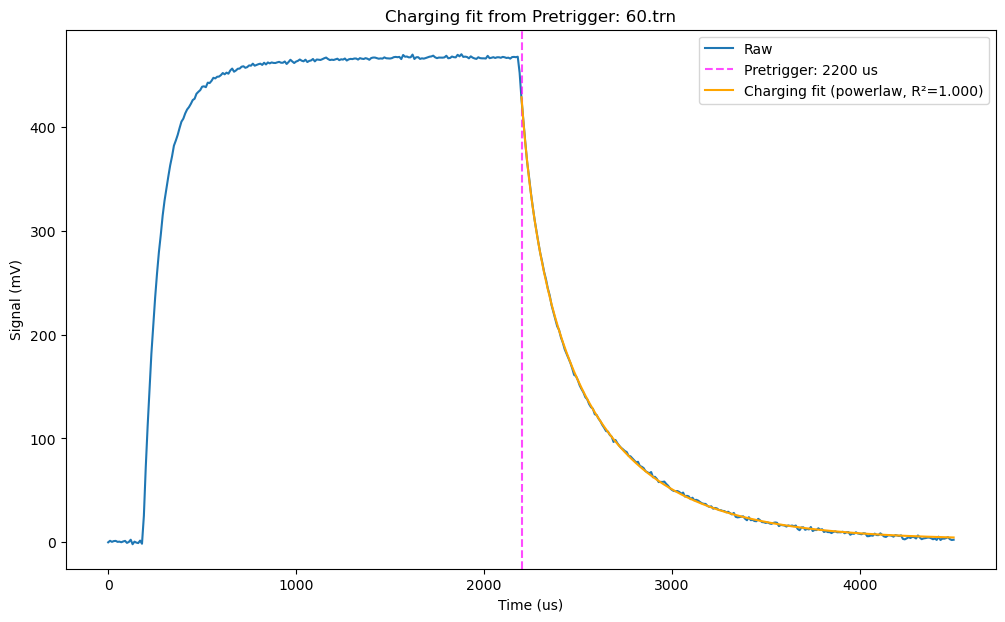

Fit parameters: A=426.155, tau=553.190, t0=68.506, n=0.283, O=2.220
R²: 0.9998


In [78]:
fit_charging_from_pretrigger('gregorio-jaca-peter-tallosy_ePCD/first/60.trn', model='powerlaw')

In [79]:
# Batch process all .trn files, fit charging, extract header, and save results to CSV
import os
import pandas as pd
from glob import glob

def batch_fit_charging_and_save_csv(root_dir, csv_path='charging_fit_results.csv', model='exp'):
    results = []
    # Recursively find all .trn files, including subdirectories
    all_trn = []
    for dirpath, _, _ in os.walk(root_dir):
        files = glob(os.path.join(dirpath, '*.trn'))
        all_trn.extend(files)
    # Sort by directory then filename
    all_trn = sorted(all_trn, key=lambda x: (os.path.relpath(os.path.dirname(x), root_dir), os.path.basename(x)))
    for f in all_trn:
        try:
            times, values = read_trn_file(f)
            header, time_unit, voltage_unit = parse_trn_header(f)
            # Fit charging region
            pre_val = header.get('Pretrigger', None)
            if pre_val is None:
                continue
            pre_num = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', pre_val)[0])
            if 'us' in pre_val:
                pre_time = pre_num
            elif 'ns' in pre_val:
                pre_time = pre_num / 1000.0
            else:
                pre_time = pre_num
            start_idx = np.argmax(times >= pre_time)
            x = times[start_idx:] - times[start_idx]
            y = values[start_idx:]

            if model == 'exp':
                C0 = min(y)
                A0 = max(y) - min(y)
                tau0 = (x[-1] - x[0]) / 3 if (x[-1] - x[0]) > 0 else 1.0
                p0 = [A0, tau0, C0]
                bounds = ([0, 0, min(y)], [np.inf, np.inf, max(y)])
                fit_func = charging_func_exp
            elif model == 'powerlaw':
                A0 = max(y) - min(y)
                tau0 = (x[-1] - x[0]) / 2 if (x[-1] - x[0]) > 0 else 1.0
                t0_0 = tau0
                n0 = 1.0
                O0 = min(y)
                p0 = [A0, tau0, t0_0, n0, O0]
                bounds = ([0, 0, 0, 0, min(y)], [np.inf, np.inf, np.inf, 5, max(y)])
                fit_func = charging_func_powerlaw
            else:
                continue

            popt, _ = curve_fit(fit_func, x, y, p0=p0, bounds=bounds, maxfev=5000)
            yfit = fit_func(x, *popt)
            ss_res = np.sum((y - yfit) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf
            # Collect header and fit results
            row = {
                'file': os.path.relpath(f, root_dir),
                'r2': r2
            }
            if model == 'exp':
                row.update({'tau': popt[1], 'A': popt[0], 'C': popt[2]})
            else:
                row.update({'tau': popt[1], 'A': popt[0], 't0': popt[2], 'n': popt[3], 'O': popt[4]})
            for k, v in header.items():
                row[k] = v
            results.append(row)
        except Exception as e:
            print(f'Error processing {f}: {e}')
    df = pd.DataFrame(results)
    if model == 'exp':
        fit_cols = ['file', 'tau', 'A', 'C', 'r2']
    else:
        fit_cols = ['file', 'tau', 'A', 't0', 'n', 'O', 'r2']
    header_cols = [c for c in df.columns if c not in fit_cols]
    df = df[fit_cols + header_cols]
    df.to_csv(csv_path, index=False)
    print(f'Saved results to {csv_path}')

# Example usage:
# batch_fit_charging_and_save_csv("gregorio-jaca-peter-tallosy_ePCD", model='exp')
batch_fit_charging_and_save_csv("gregorio-jaca-peter-tallosy_ePCD", model='powerlaw')


Saved results to charging_fit_results.csv


In [80]:
# Post-process charging_fit_results.csv: plot tau and Lifetime vs intensity for each relevant subdirectory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv('charging_fit_results.csv')

# Only keep rows where 'file' matches pattern: subdir(s)/intensity.trn
pattern = re.compile(r'(.+[\\/])?(\d+)\.trn$')
relevant = df['file'].apply(lambda x: bool(pattern.match(x)))
df_relevant = df[relevant].copy()

# Extract subdirectory and intensity
def extract_subdir_intensity(f):
    m = pattern.match(f)
    if m:
        subdir = m.group(1) or ''
        intensity = int(m.group(2))
        return subdir.rstrip('\\/'), intensity
    return None, None

df_relevant[['subdir', 'intensity']] = df_relevant['file'].apply(lambda f: pd.Series(extract_subdir_intensity(f)))


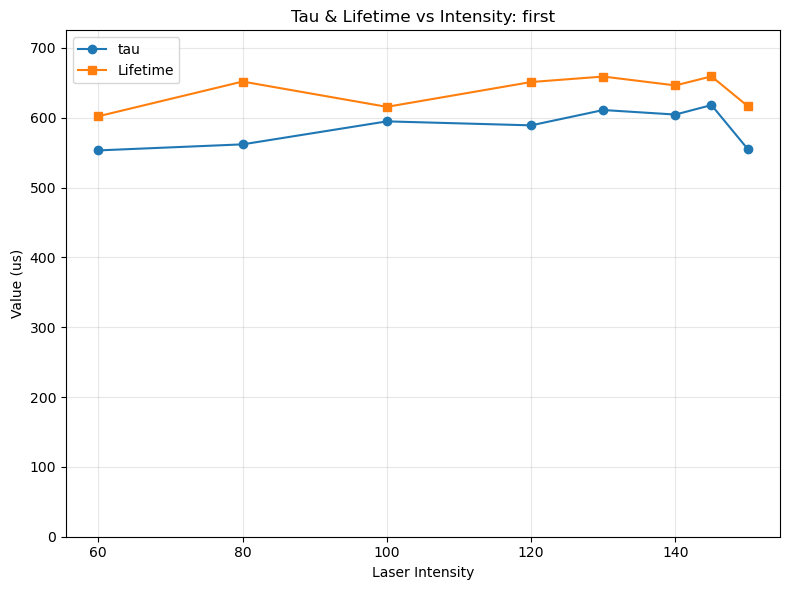

7    602.06
8    651.77
1    615.55
2    651.10
3    658.94
4    646.23
5    659.20
6    616.85
Name: Lifetime_float, dtype: float64
7    553.189990
8    561.846790
1    594.764533
2    589.057108
3    611.006984
4    604.519943
5    618.107690
6    555.516367
Name: tau, dtype: float64


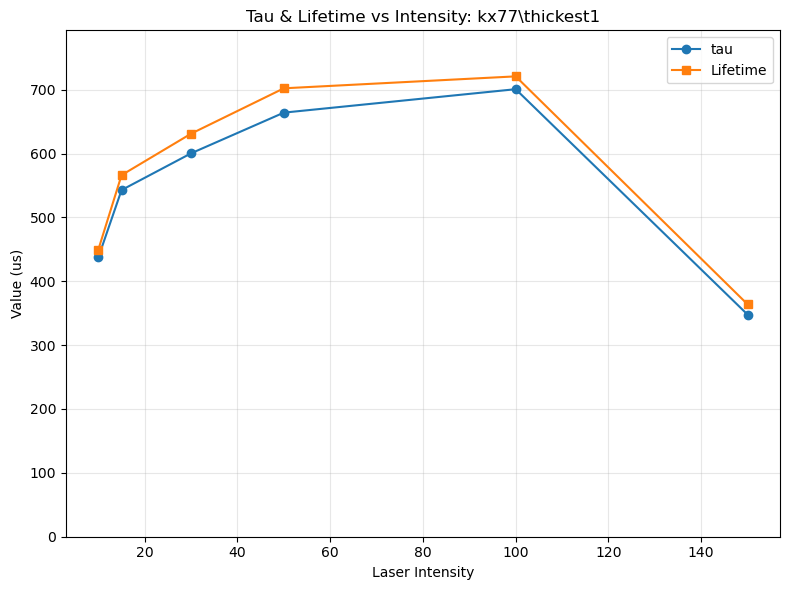

12    449.62
14    566.13
16    631.08
17    702.10
13    720.79
15    363.93
Name: Lifetime_float, dtype: float64
12    437.343867
14    542.772643
16    600.319184
17    664.014241
13    700.712238
15    347.867462
Name: tau, dtype: float64


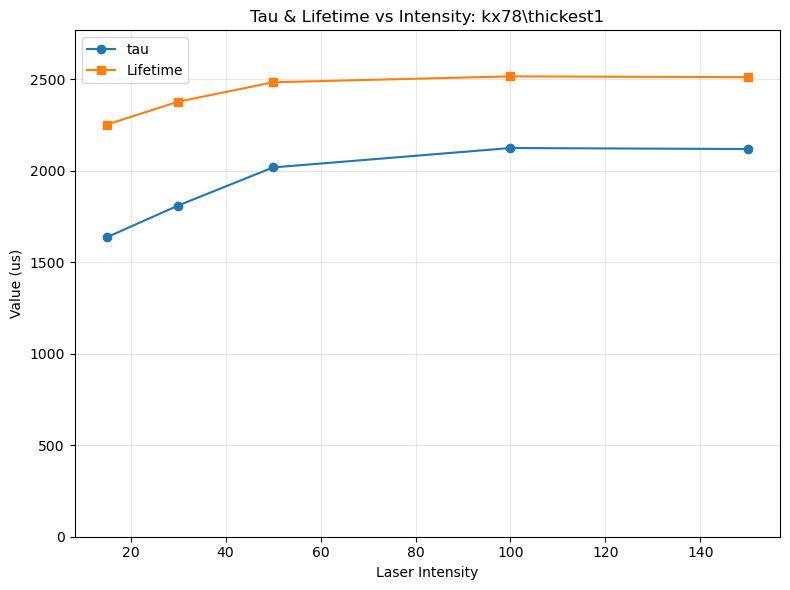

22    2252.7
24    2378.1
25    2484.2
21    2516.5
23    2512.1
Name: Lifetime_float, dtype: float64
22    1637.094226
24    1810.183020
25    2018.714955
21    2124.805665
23    2119.332304
Name: tau, dtype: float64


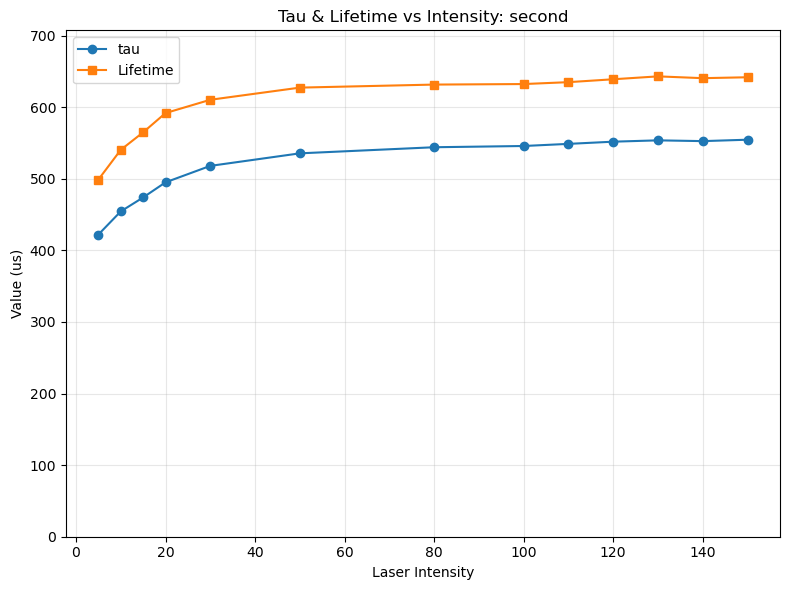

36    498.76
26    540.32
32    564.81
34    591.72
35    610.28
37    627.27
38    631.51
27    632.25
28    634.89
29    638.93
30    642.98
31    640.46
33    641.73
Name: Lifetime_float, dtype: float64
36    422.007226
26    454.351388
32    473.862716
34    494.972744
35    517.959655
37    535.470309
38    543.992639
27    545.728765
28    548.692688
29    551.757686
30    553.619440
31    552.540162
33    554.513029
Name: tau, dtype: float64


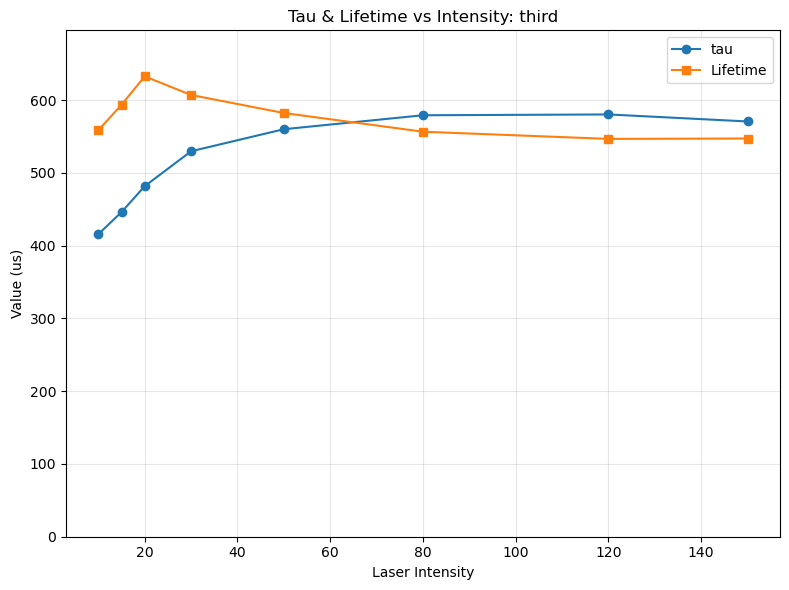

39    558.69
41    593.66
43    632.65
44    607.07
45    582.29
46    556.59
40    546.71
42    547.25
Name: Lifetime_float, dtype: float64
39    415.760991
41    446.143436
43    481.756550
44    529.731701
45    560.041117
46    579.197105
40    580.316046
42    570.688812
Name: tau, dtype: float64


In [81]:
# Joint plot: tau and Lifetime vs intensity for each subdirectory, Lifetime parsed to float
for subdir, group in df_relevant.groupby('subdir'):
    group_sorted = group.sort_values('intensity').copy()

    # Individual Lifetime plot (parse float from Lifetime column)
    if 'Lifetime' in group_sorted.columns:
        # # Extract float from Lifetime string (e.g., '757.97 us')
        group_sorted['Lifetime_float'] = group_sorted['Lifetime'].astype(str).str.extract(r'([\d\.]+)').astype(float)

        # Joint plot
        plt.figure(figsize=(8,6))
        plt.plot(group_sorted['intensity'], group_sorted['tau'], 'o-', label='tau')
        plt.plot(group_sorted['intensity'], group_sorted['Lifetime_float'], 's-', label='Lifetime')
        plt.xlabel('Laser Intensity')
        plt.ylabel('Value (us)')
        plt.title(f'Tau & Lifetime vs Intensity: {subdir}')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.1*max(max(group_sorted['tau']), max(group_sorted['Lifetime_float'])))
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(group_sorted['Lifetime_float'])
        print(group_sorted['tau'])
    else:
        print(f'No Lifetime column found for {subdir}')

In [82]:
# Extract tau_eff (Lifetime_float) for each filename from joint plot data
# Assumes df_relevant is available from previous cells

tau_eff_dict = {}
for subdir, group in df_relevant.groupby('subdir'):
    group_sorted = group.sort_values('intensity').copy()
    if 'Lifetime' in group_sorted.columns:
        group_sorted['Lifetime_float'] = group_sorted['Lifetime'].astype(str).str.extract(r'([\d\.]+)').astype(float)
        for _, row in group_sorted.iterrows():
            # Compose full filename as in results dict
            if subdir:
                fname = f"{subdir}/{row['intensity']}.trn" if 'intensity' in row else f"{subdir}/{row['file']}"
            else:
                fname = row['file']
            tau_eff_dict[fname] = row['Lifetime_float']
    else:
        print(f'No Lifetime column found for {subdir}')

# Print tau_eff_dict for inspection
for k, v in tau_eff_dict.items():
    print(f'{k}: {v}')

first/60.trn: 602.06
first/80.trn: 651.77
first/100.trn: 615.55
first/120.trn: 651.1
first/130.trn: 658.94
first/140.trn: 646.23
first/145.trn: 659.2
first/150.trn: 616.85
kx77\thickest1/10.trn: 449.62
kx77\thickest1/15.trn: 566.13
kx77\thickest1/30.trn: 631.08
kx77\thickest1/50.trn: 702.1
kx77\thickest1/100.trn: 720.79
kx77\thickest1/150.trn: 363.93
kx78\thickest1/15.trn: 2252.7
kx78\thickest1/30.trn: 2378.1
kx78\thickest1/50.trn: 2484.2
kx78\thickest1/100.trn: 2516.5
kx78\thickest1/150.trn: 2512.1
second/5.trn: 498.76
second/10.trn: 540.32
second/15.trn: 564.81
second/20.trn: 591.72
second/30.trn: 610.28
second/50.trn: 627.27
second/80.trn: 631.51
second/100.trn: 632.25
second/110.trn: 634.89
second/120.trn: 638.93
second/130.trn: 642.98
second/140.trn: 640.46
second/150.trn: 641.73
third/10.trn: 558.69
third/15.trn: 593.66
third/20.trn: 632.65
third/30.trn: 607.07
third/50.trn: 582.29
third/80.trn: 556.59
third/120.trn: 546.71
third/150.trn: 547.25


In [83]:
tau_eff_dict.keys()

dict_keys(['first/60.trn', 'first/80.trn', 'first/100.trn', 'first/120.trn', 'first/130.trn', 'first/140.trn', 'first/145.trn', 'first/150.trn', 'kx77\\thickest1/10.trn', 'kx77\\thickest1/15.trn', 'kx77\\thickest1/30.trn', 'kx77\\thickest1/50.trn', 'kx77\\thickest1/100.trn', 'kx77\\thickest1/150.trn', 'kx78\\thickest1/15.trn', 'kx78\\thickest1/30.trn', 'kx78\\thickest1/50.trn', 'kx78\\thickest1/100.trn', 'kx78\\thickest1/150.trn', 'second/5.trn', 'second/10.trn', 'second/15.trn', 'second/20.trn', 'second/30.trn', 'second/50.trn', 'second/80.trn', 'second/100.trn', 'second/110.trn', 'second/120.trn', 'second/130.trn', 'second/140.trn', 'second/150.trn', 'third/10.trn', 'third/15.trn', 'third/20.trn', 'third/30.trn', 'third/50.trn', 'third/80.trn', 'third/120.trn', 'third/150.trn'])

so the semilab WT-1200I gives you a value for Lifetime, but I also fitted manually (getting very good fit quality r2 ~ 0.99) and the two values are quite similar

Let's move on to task 9

this is good

In [84]:
import math

In [85]:
def calculate_mobility_and_properties(
    material='c-Si', 
    dopant_species='P', 
    Ndop=1.0e16, 
    Delta_n=1.0e15, 
    Delta_p=1.0e15, 
    T=300.0,
    tau_eff_e=10e-6, 
    tau_eff_h=10e-6
):
    """
    Calculates carrier mobilities, diffusivities, and diffusion lengths for Silicon
    using the Klaassen Unified Mobility Model logic (PV Lighthouse).
    
    Inputs:
        material      : 'c-Si' (Only Silicon implemented)
        dopant_species: 'P' (Phosphorus, n-type) or 'B' (Boron, p-type)
        Ndop          : Substitutional dopant concentration [cm^-3]
        Delta_n       : Excess electron concentration [cm^-3]
        Delta_p       : Excess hole concentration [cm^-3]
        T             : Temperature [K]
        tau_eff_e     : Effective electron lifetime [s]
        tau_eff_h     : Effective hole lifetime [s]
        
    Returns:
        Dictionary containing n0, p0, n, p, mu_e, mu_h, mu_a, 
        De, Dh, Da, Le, Lh, La, rho0, rho
    """
    
    # --- Constants ---
    q = 1.60217663e-19
    k_B = 1.380649e-23
    kB_T = k_B * T
    VT = kB_T / q  # Thermal voltage

    # --- Intrinsic Carrier Concentration (ni) ---
    # Standard approximation for Si near 300K
    ni = 9.65e9 * (T / 300.0)**1.5

    # --- 1. Equilibrium Carrier Concentrations ---
    # Assuming complete ionisation (N_ionised = Ndop)
    N_ionised = Ndop
    
    if dopant_species == 'P':  # n-type
        n0 = N_ionised
        p0 = ni**2 / N_ionised
        # Scattering Centers for Equilibrium
        N_D = N_ionised
        N_A = 0.0
    elif dopant_species == 'B':  # p-type
        p0 = N_ionised
        n0 = ni**2 / N_ionised
        # Scattering Centers for Equilibrium
        N_D = 0.0
        N_A = N_ionised
    else:
        raise ValueError("Dopant species must be 'P' or 'B'")

    # --- 2. Steady-state Carrier Concentrations ---
    n = n0 + Delta_n
    p = p0 + Delta_p

    # --- 3. Mobility Calculation (Klaassen Model) ---
    
    # Klaassen Parameters for Silicon (from literature/PV Lighthouse defaults)
    # Electrons
    mu_max_e = 1414.0
    mu_min_e = 68.5
    theta_e = 2.285
    alpha_e = 0.711
    Nref_e = 9.20e16
    
    # Holes
    mu_max_h = 470.5
    mu_min_h = 44.9
    theta_h = 2.247
    alpha_h = 0.719
    Nref_h = 2.23e17

    # Lattice Scattering (Temperature Dependent)
    mu_L_e = mu_max_e * (T / 300.0)**(-theta_e)
    mu_L_h = mu_max_h * (T / 300.0)**(-theta_h)

    # Effective Scattering Densities (N_sc)
    # CRITICAL FIX: Majority carriers do NOT scatter off themselves.
    # N_sc_e (for electrons) = Donors + Acceptors + Holes
    # N_sc_h (for holes)     = Donors + Acceptors + Electrons
    
    # Steady-State N_sc
    N_sc_e = N_D + N_A + p
    N_sc_h = N_D + N_A + n
    
    # Equilibrium N_sc (for rho0)
    N_sc_e0 = N_D + N_A + p0
    N_sc_h0 = N_D + N_A + n0

    # -- Helper Function for Klaassen/Masetti Interpolation --
    def calculate_mu_imp(mu_min, mu_max, mu_L, N_sc, Nref, alpha):
        # Impurity scattering component combined with lattice
        # Standard Caughey-Thomas like form used in Klaassen
        term = (N_sc / Nref)**alpha
        mu_impurity_part = mu_min + (mu_max - mu_min) / (1 + term)
        
        # Matthiessen's rule combination (Simplified for implementation stability)
        # 1/mu = 1/mu_L + 1/mu_impurity_part - correction
        # For this script, we use the direct analytical function often used:
        # mu = mu_min + (mu_L - mu_min) / (1 + (N_sc/Nref)^alpha) 
        # Note: We use mu_L in place of mu_max to account for T-dependence of the lattice limit.
        
        return mu_min + (mu_L - mu_min) / (1 + term)

    # Calculate Steady-State Mobilities
    mu_e = calculate_mu_imp(mu_min_e, mu_max_e, mu_L_e, N_sc_e, Nref_e, alpha_e)
    mu_h = calculate_mu_imp(mu_min_h, mu_max_h, mu_L_h, N_sc_h, Nref_h, alpha_h)
    
    # Calculate Equilibrium Mobilities (for rho0)
    mu_e0 = calculate_mu_imp(mu_min_e, mu_max_e, mu_L_e, N_sc_e0, Nref_e, alpha_e)
    mu_h0 = calculate_mu_imp(mu_min_h, mu_max_h, mu_L_h, N_sc_h0, Nref_h, alpha_h)

    # --- 4. Ambipolar Mobility ---
    # Formula: mu_a = (n + p) * mu_e * mu_h / (n * mu_e + p * mu_h)
    mu_a = (n + p) * mu_e * mu_h / (n * mu_e + p * mu_h)

    # --- 5. Diffusivities ---
    # D = mu * k * T / q
    De = mu_e * VT
    Dh = mu_h * VT
    Da = mu_a * VT

    # --- 6. Diffusion Lengths ---
    # L = sqrt(D * tau)
    Le = math.sqrt(De * tau_eff_e)
    Lh = math.sqrt(Dh * tau_eff_h)
    
    # Ambipolar Diffusion Length (La)
    # Using the minority lifetime for the ambipolar length is standard
    if dopant_species == 'P': # n-type, holes are minority
        tau_a = tau_eff_h
    else:                     # p-type, electrons are minority
        tau_a = tau_eff_e
    La = math.sqrt(Da * tau_a)

    # --- 7. Resistivities ---
    # rho0 = 1 / [q * (mu_e0 * n0 + mu_h0 * p0)]
    rho0 = 1.0 / (q * (mu_e0 * n0 + mu_h0 * p0))
    # rho = 1 / [q * (mu_e * n + mu_h * p)]
    rho = 1.0 / (q * (mu_e * n + mu_h * p))

    # print(tau_eff_e, tau_eff_h)

    return {
        "n0": n0, "p0": p0,
        "n": n, "p": p,
        "mu_e": mu_e, "mu_h": mu_h, "mu_a": mu_a,
        "De": De, "Dh": Dh, "Da": Da,
        "Le": Le, "Lh": Lh, "La": La,
        "rho0": rho0, "rho": rho
    }

In [86]:
# --- Example Usage ---
# c-Si, P-doped, Ndop=1e16, Delta_n=1e15, T=300K
results = calculate_mobility_and_properties(
    material='c-Si', dopant_species='P', 
    Ndop=1719580180010960, Delta_n=1719580180010960, Delta_p=1719580180010960, T=300,
    tau_eff_e=0.00072079, tau_eff_h=0.00072079
)

print("-" * 30)
print(f"Mobilities (cm^2/Vs):")
print(f"  mu_e: {results['mu_e']:.2f}")
print(f"  mu_h: {results['mu_h']:.2f}")
print(f"  mu_a: {results['mu_a']:.2f}")
print("-" * 30)
print(f"Diffusion Lengths (cm):")
print(f"  Le: {results['Le']:.4f}")
print(f"  Lh: {results['Lh']:.4f}")
print(f"  La: {results['La']:.4f}")
print("-" * 30)

------------------------------
Mobilities (cm^2/Vs):
  mu_e: 1295.43
  mu_h: 443.90
  mu_a: 568.46
------------------------------
Diffusion Lengths (cm):
  Le: 0.1554
  Lh: 0.0909
  La: 0.1029
------------------------------


this gives almost the same value as the website. i just needed somthing that i could run iteratively in code

this website has the model

https://www2.pvlighthouse.com.au/calculators/mobility%20calculator/mobility%20calculator.aspx 

In [87]:
# old
# Constants
q = 1.60217663e-19  # Electron charge [C]

def calculate_transient_delta_n(
    sigma_s_series, 
    W, 
    Ndop, 
    tau_eff,
    dopant_species='B', 
    T=300.0, 
    sigma_s_background=None, # New optional parameter
    tolerance=1e-3, 
    max_iter=20
):
    """
    Iteratively calculates the excess carrier concentration Delta_n(t) from a 
    time-series of sheet conductance values using the iterative mobility correction.

    Parameters:
    -----------
    sigma_s_series : array-like
        Time-series of total sheet conductance [S]. 
        Calculated as: conductance_from_voltage(voltages)
    W : float
        Wafer thickness [cm].
    Ndop : float
        Doping concentration [cm^-3].
    tau_eff : float
        Effective lifetime for this file [s].
    dopant_species : str
        'P' for Phosphorus (n-type) or 'B' for Boron (p-type).
    T : float
        Temperature [K].
    tolerance : float
        Convergence criteria (relative change).
    max_iter : int
        Maximum number of iterations per point.

    Returns:
    --------
    delta_n_series : np.array
        Time-series of excess carrier concentration [cm^-3].
    """
    
    sigma_s_series = np.array(sigma_s_series)
    delta_n_series = np.zeros_like(sigma_s_series, dtype=float)

    delta_n_converged = np.zeros_like(sigma_s_series, dtype=float)
    
    # Initial guess for Delta_n (e.g., 1e14 cm^-3 or similar)
    # We maintain the guess between time steps to speed up convergence 
    # as Delta_n(t) changes continuously.
    current_dn_guess = 1.0e14 

    # Loop through each time point in the series
    for i, sigma_s in enumerate(sigma_s_series):
        
        # Iterative Solver for this specific time point
        for iteration in range(max_iter):
            
            # 1. Get Mobilities based on current guess of Delta_n
            # We assume Delta_n = Delta_p
            props = calculate_mobility_and_properties(
                material='c-Si',
                dopant_species=dopant_species,
                Ndop=Ndop,
                Delta_n=current_dn_guess,
                Delta_p=current_dn_guess,
                T=T,
                tau_eff_e=tau_eff, 
                tau_eff_h=tau_eff
            )
            
            mu_e = props['mu_e']
            mu_h = props['mu_h']
            
            # 2. Identify Majority and Sum Mobilities
            mu_sum = mu_e + mu_h
            if dopant_species == 'P': # n-type
                mu_maj = mu_e
            else: # p-type
                mu_maj = mu_h
            
            # [cite_start]3. Calculate new Delta_n [cite: 355]
            # Formula: dn = (sigma/W - q*N*mu_maj) / (q*mu_sum)
            # Note: q is added to the N*mu term for unit consistency (Conductivity = q*n*mu)

            conductivity_total = sigma_s / W
            conductivity_background = q * Ndop * mu_maj
            delta_n_new = (conductivity_total - conductivity_background) / (q * mu_sum)
            
            # 4. Sanity Check / Damping
            # Prevent negative values if signal is noisy/below background
            if delta_n_new < 1e10:
                delta_n_new = 1e10
                
            # 5. Check Convergence
            if current_dn_guess > 0:
                rel_error = abs(delta_n_new - current_dn_guess) / current_dn_guess
            else:
                rel_error = 1.0
                
            current_dn_guess = delta_n_new
            
            if rel_error < tolerance:
                delta_n_converged[i] = 1
                break
        
        # Store the converged result for this time step
        delta_n_series[i] = current_dn_guess

    return delta_n_series, delta_n_converged

In [88]:
# filepath = 'gregorio-jaca-peter-tallosy_ePCD/kx77/thickest2.trn'
# Ndop = 1719580180010960
# W = 0.99
# V_background = 1.373


# times, voltages = read_trn_file(filepath)
# header, time_unit, voltage_unit = parse_trn_header(filepath)
# # Find Pretrigger value
# if 'Pretrigger' not in header:
#     raise ValueError('Pretrigger not found in header')
# pre_val = header['Pretrigger']
# pre_num = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', pre_val)[0])
# # Convert units if needed
# if 'us' in pre_val:
#     pre_time = pre_num
# elif 'ns' in pre_val:
#     pre_time = pre_num / 1000.0
# else:
#     pre_time = pre_num
# # Find index where time >= pretrigger
# start_idx = np.argmax(times >= pre_time)
# x = times[start_idx:] - times[start_idx]  # shift to t=0 at pretrigger
# y = voltages[start_idx:]
# sigma_s_series = conductance_from_voltage(y)

# T=300.0
# # old
# delta_n_series, delta_n_converged = calculate_transient_delta_n(
#     sigma_s_series, 
#     W=W, 
#     Ndop=Ndop, 
#     dopant_species='B', 
#     T=T, 
#     tau_eff=tau_eff_dict['kx77/thickest2.trn']
#     tolerance=1e-5, 
#     max_iter=100
# )

# # new
# # delta_n_series, delta_n_converged = calculate_transient_delta_n(
# #     sigma_s_series, 
# #     W, 
# #     Ndop, 
# #     dopant_species='B', 
# #     T=300.0, 
# #     sigma_s_background= conductance_from_voltage(V_background), # New optional parameter
# #     tolerance=1e-5, 
# #     max_iter=20
# # )

# print(f"percentage converged: {np.mean(delta_n_converged)*100}%")

In [89]:
# run all
import os
import re
from glob import glob

def get_pre_time(header_val):
    if header_val is None:
        return None
    s = str(header_val)
    nums = re.findall(r'[-+]?[0-9]*\.?[0-9]+', s)
    if not nums:
        return None
    pre_num = float(nums[0])
    if 'us' in s:
        return pre_num
    if 'ns' in s:
        return pre_num / 1000.0
    return pre_num  # assume microseconds if no unit

# Define wafer parameters for each sample
wafer_params = {
    'kx77': {
        'Ndop': 1719580180010960,
        'V_background': 1.373,
        'thickest1': 2.52,
        'thickest2': 0.99,
        'thickest3': 0.64,
        'thickest4': 0.70,
    },
    'kx78': {
        'Ndop': 8031752834168360,
        'V_background': 1.696,
        'thickest1': 2.40,
        'thickest2': 0.92,
        'thickest3': 0.74,
        'thickest4': 0.64,
    },
}

# New standalone samples
extra_samples = {
    'second': {
        'Ndop': 2.78e15,
        'V_background': 0.0,
        'W': 0.0151,  # 151 micrometers
    },
    'third': {
        'Ndop': 1.70e15,
        'V_background': 0.0,
        'W': 0.0153,  # 153 micrometers
    },
}

base_dir = 'gregorio-jaca-peter-tallosy_ePCD'
results = {}
tau_eff_dict = {}

def process_file(trn_path, W, Ndop, V_background, file_key):
    times, voltages = read_trn_file(trn_path)
    header, time_unit, voltage_unit = parse_trn_header(trn_path)
    pre_time = get_pre_time(header.get('Pretrigger'))
    if pre_time is None:
        print(f'No usable Pretrigger in {trn_path}')
        return
    start_idx = np.argmax(times >= pre_time)
    x = times[start_idx:] - times[start_idx]
    y = voltages[start_idx:]
    sigma_s_series = conductance_from_voltage(y)
    tau_eff = None
    for k in header:
        if 'tau' in k.lower() or 'lifetime' in k.lower():
            try:
                tau_eff = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', str(header[k]))[0])
            except Exception:
                tau_eff = None
    tau_eff_dict[file_key] = tau_eff
    delta_n_series, delta_n_converged = calculate_transient_delta_n(
        sigma_s_series,
        W,
        Ndop,
        tau_eff_dict[file_key],
        dopant_species='B',  # or 'P' if n-type, adjust as needed
        T=300.0,
        sigma_s_background=conductance_from_voltage(V_background),
        tolerance=1e-5,
        max_iter=20
    )
    results[file_key] = {
        'times': x,
        'voltages': y,
        'delta_n': delta_n_series,
        'sigma_s': sigma_s_series,
        'converged': delta_n_converged
    }

# kx77 / kx78
for wafer in ['kx77', 'kx78']:
    wafer_dir = os.path.join(base_dir, wafer)
    params = wafer_params[wafer]
    Ndop = params['Ndop']
    V_background = params['V_background']
    # Files directly in wafer dir
    for thick in ['thickest2', 'thickest3', 'thickest4']:
        trn_path = os.path.join(wafer_dir, f'{thick}.trn')
        if os.path.exists(trn_path):
            process_file(trn_path, params[thick], Ndop, V_background, f'{wafer}/{thick}')
    # thickest1 subfolder
    thick1_dir = os.path.join(wafer_dir, 'thickest1')
    if os.path.isdir(thick1_dir):
        W = params['thickest1']
        for trn_file in glob(os.path.join(thick1_dir, '*.trn')):
            fname = os.path.basename(trn_file)
            process_file(trn_file, W, Ndop, V_background, f'{wafer}/thickest1/{fname}')

# Standalone dirs: second and third
for wafer, props in extra_samples.items():
    wafer_dir = os.path.join(base_dir, wafer)
    if not os.path.isdir(wafer_dir):
        print(f'Skipping missing dir: {wafer_dir}')
        continue
    Ndop = props['Ndop']
    V_background = props.get('V_background', 0.0)
    W = props['W']
    for trn_file in glob(os.path.join(wafer_dir, '*.trn')):
        fname = os.path.basename(trn_file)
        process_file(trn_file, W, Ndop, V_background, f'{wafer}/{fname}')

In [90]:
print('tau_eff_dict:')
for k, v in tau_eff_dict.items():
    print(f'{k}: {v}')

tau_eff_dict:
kx77/thickest2: 728.03
kx77/thickest3: 595.66
kx77/thickest4: 611.91
kx77/thickest1/10.trn: 449.62
kx77/thickest1/100.trn: 720.79
kx77/thickest1/15.trn: 566.13
kx77/thickest1/150.trn: 363.93
kx77/thickest1/30.trn: 631.08
kx77/thickest1/50.trn: 702.1
kx78/thickest2: 3071.6
kx78/thickest3: 2801.9
kx78/thickest4: 2632.5
kx78/thickest1/100.trn: 2516.5
kx78/thickest1/15.trn: 2252.7
kx78/thickest1/150.trn: 2512.1
kx78/thickest1/30.trn: 2378.1
kx78/thickest1/50.trn: 2484.2
second/10.trn: 540.32
second/100.trn: 632.25
second/110.trn: 634.89
second/120.trn: 638.93
second/130.trn: 642.98
second/140.trn: 640.46
second/15.trn: 564.81
second/150.trn: 641.73
second/20.trn: 591.72
second/30.trn: 610.28
second/5.trn: 498.76
second/50.trn: 627.27
second/80.trn: 631.51
third/10.trn: 558.69
third/120.trn: 546.71
third/15.trn: 593.66
third/150.trn: 547.25
third/20.trn: 632.65
third/30.trn: 607.07
third/50.trn: 582.29
third/80.trn: 556.59


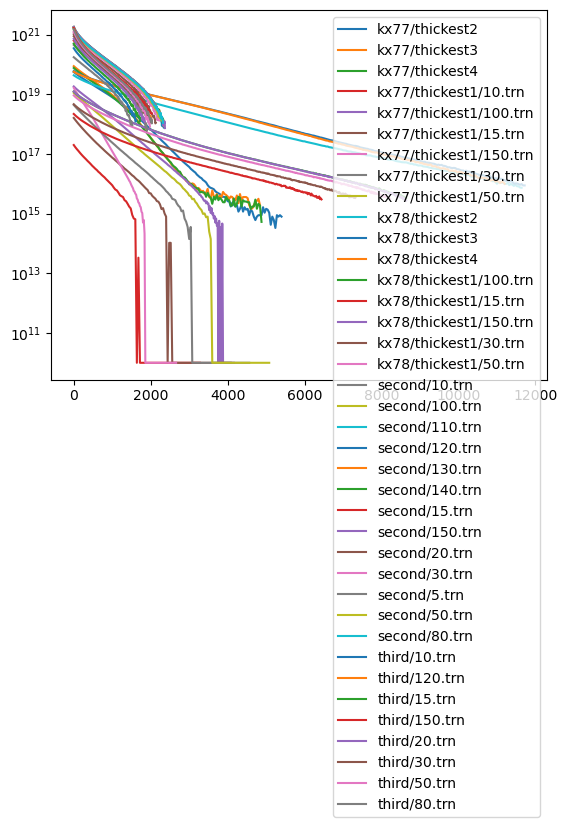

In [91]:
# Now 'results' contains delta_n for all files in kx77 and kx78, with correct W and Ndop
# You can further analyze or plot as needed, e.g.:
for key, val in results.items():
    plt.plot(val['times'], val['delta_n'], label=key)
    plt.yscale('log')
plt.legend()
plt.show()

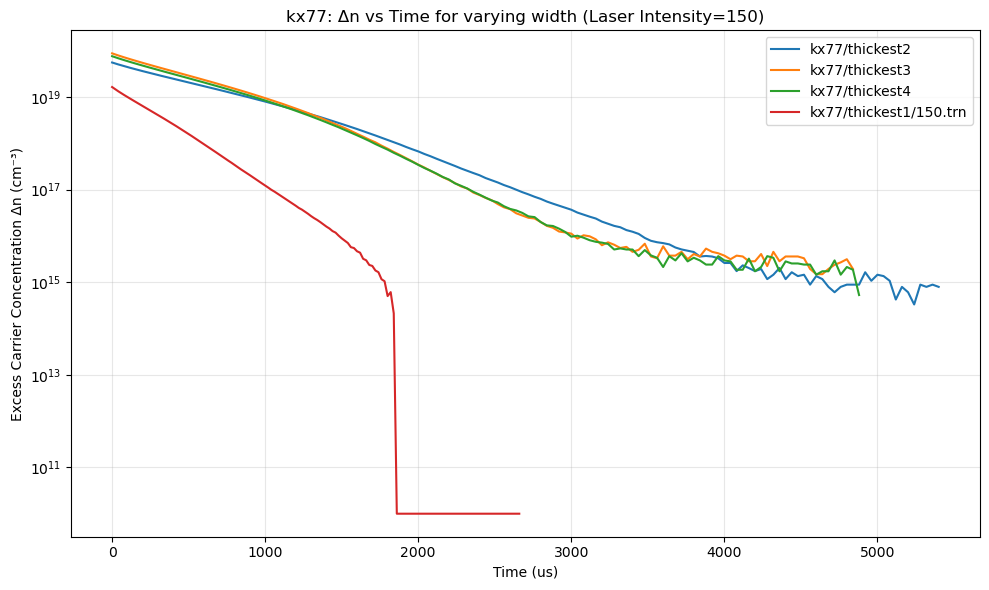

In [92]:
# Plot delta_n vs time for selected kx77 files
import matplotlib.pyplot as plt

# First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
plt.figure(figsize=(10,6))
for key in [
    'kx77/thickest2',
    'kx77/thickest3',
    'kx77/thickest4',
    'kx77/thickest1/150.trn'
]:
    if key in results:
        plt.plot(results[key]['times'], results[key]['delta_n'], label=key)
        plt.yscale('log')

    else:
        print(f'Missing: {key}')
plt.xlabel('Time (us)')
plt.ylabel('Excess Carrier Concentration Δn (cm⁻³)')
plt.title('kx77: Δn vs Time for varying width (Laser Intensity=150)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [93]:
# # Plot delta_n vs time for selected kx77 files
# import matplotlib.pyplot as plt

# # First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
# plt.figure(figsize=(10,6))
# for key in [
#     'kx78/thickest2',
#     'kx78/thickest3',
#     'kx78/thickest4',
#     'kx78/thickest1/150.trn'
# ]:
#     if key in results:
#         plt.plot(results[key]['times'], results[key]['delta_n'], label=key)
#         plt.yscale('log')

#     else:
#         print(f'Missing: {key}')
# plt.xlabel('Time (us)')
# plt.ylabel('Excess Carrier Concentration Δn (cm⁻³)')
# plt.title('kx78: Δn vs Time for varying width (Laser Intensity=150)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()



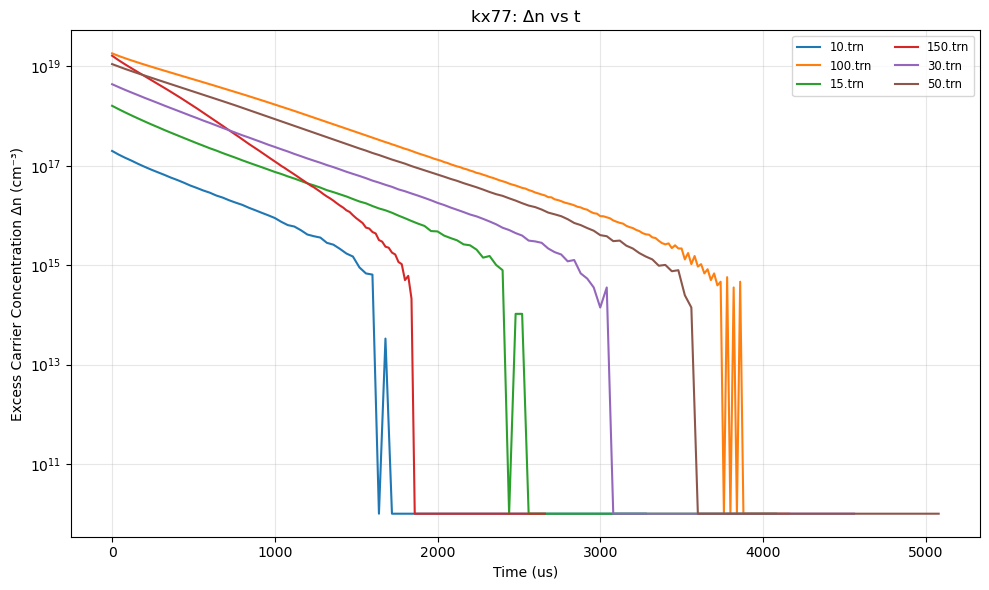

In [94]:
# Second plot: all thickest1/*.trn files in kx77
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('kx77/thickest1/')]
for key in sorted(thick1_keys):
    plt.plot(results[key]['times'], results[key]['delta_n'], label=key.split('/')[-1])
    plt.yscale('log')
plt.xlabel('Time (us)')
plt.ylabel('Excess Carrier Concentration Δn (cm⁻³)')
plt.title('kx77: Δn vs t')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
# # Second plot: all thickest1/*.trn files in kx77
# plt.figure(figsize=(10,6))
# thick1_keys = [k for k in results if k.startswith('kx78/thickest1/')]
# for key in sorted(thick1_keys):
#     plt.plot(results[key]['times'], results[key]['delta_n'], label=key.split('/')[-1])
#     plt.yscale('log')
# plt.xlabel('Time (us)')
# plt.ylabel('Excess Carrier Concentration Δn (cm⁻³)')
# plt.title('kx78: Δn vs t')
# plt.legend(ncol=2, fontsize='small')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

the dn has to go down with time

In [96]:
# calculate tau(dn)
from scipy.signal import savgol_filter

def calculate_tau_series(
    results_dict, 
    advanced_smoothing=True, 
    window_length=15, 
    polyorder=2
):
    """
    Calculates the effective lifetime tau(Delta_n) for each entry in the results dict.
    
    [cite_start]Formula: tau = Delta_n / |d(Delta_n)/dt| [cite: 147]
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary containing 'times' and 'delta_n' for each measurement.
    advanced_smoothing : bool
        If True, applies Savitzky-Golay smoothing to Delta_n before differentiation 
        to reduce noise.
    window_length : int
        Window length for the smoothing filter (must be odd). 
        Increase this for more smoothing (reduces noise but might blur features).
    polyorder : int
        Polynomial order for the smoothing fit.
        
    Modifies:
    ---------
    results_dict : Adds 'tau_n_series' key to each sub-dictionary.
    """
    
    for key, data in results_dict.items():
        times = np.array(data['times'])
        delta_n = np.array(data['delta_n'])
        
        # Check if arrays are empty or too short
        if len(times) < window_length:
            continue

        if advanced_smoothing:
            # --- Advanced Method: Savitzky-Golay Filter ---
            # 1. Smooth the Delta_n curve to remove noise
            # Note: window_length must be odd
            if window_length % 2 == 0:
                window_length += 1
                
            delta_n_smooth = savgol_filter(delta_n, window_length, polyorder)
            
            # 2. Differentiate the smoothed curve w.r.t actual times
            # np.gradient handles non-uniform time steps automatically
            dn_dt = np.gradient(delta_n_smooth, times)
            
            # Use the smoothed Delta_n for the calculation as well
            numerator = delta_n_smooth
            
        else:
            # --- Simple Method: Raw Gradient ---
            dn_dt = np.gradient(delta_n, times)
            numerator = delta_n

        # --- Calculate Lifetime ---
        # tau = Delta_n / |d(Delta_n)/dt|
        # We use absolute value because decay slope is negative
        abs_slope = np.abs(dn_dt)
        
        # Avoid division by zero
        # Replace 0 with a very small number (or nan) to prevent errors
        abs_slope[abs_slope == 0] = 1e-10
        
        tau_series = numerator / abs_slope
        
        # Store the result
        data['tau_n_series'] = tau_series

# --- Usage Example ---
# Simple calculation
# calculate_tau_series(results, advanced_smoothing=False)

# Advanced calculation (Recommended for cleaner curves)
calculate_tau_series(results, advanced_smoothing=True, window_length=21, polyorder=3)

# Accessing the result
# sample_key = list(results.keys())[0]
# print(results[sample_key].keys()) 
# Output: dict_keys(['times', 'delta_n', 'converged', 'tau_n_series']) 

above here you can try out different window_length=21 until you find sth nice

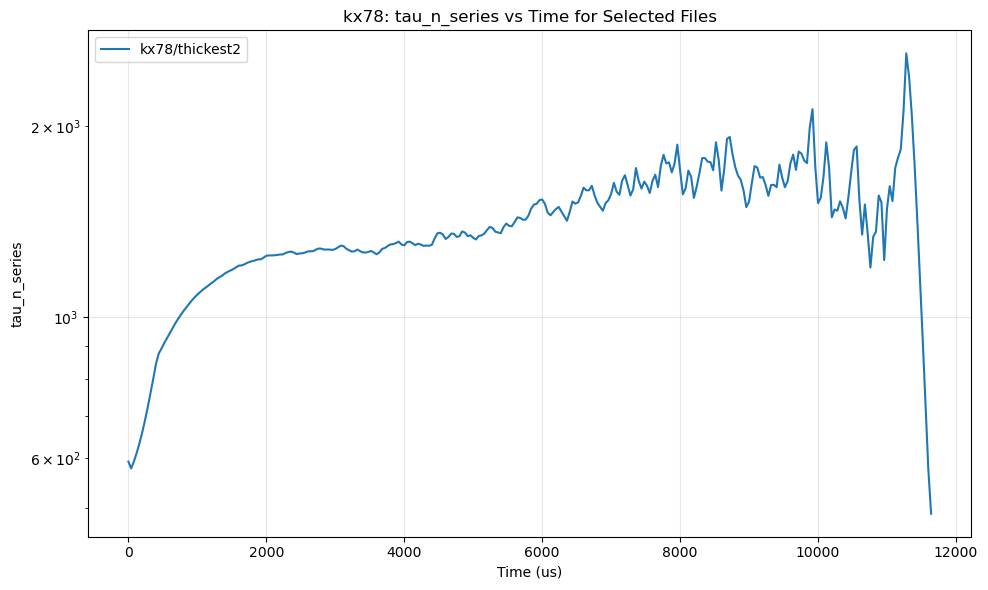

In [97]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
plt.figure(figsize=(10,6))
for key in [
    'kx78/thickest2',
    # 'kx78/thickest3',
    # 'kx78/thickest4',
    # 'kx78/thickest1/150.trn'
]:
    if key in results:
        plt.plot(results[key]['times'], results[key]['tau_n_series'], label=key)
        plt.yscale('log')
    else:
        print(f'Missing: {key}')
plt.xlabel('Time (us)')
plt.ylabel('tau_n_series')
plt.title('kx78: tau_n_series vs Time for Selected Files')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

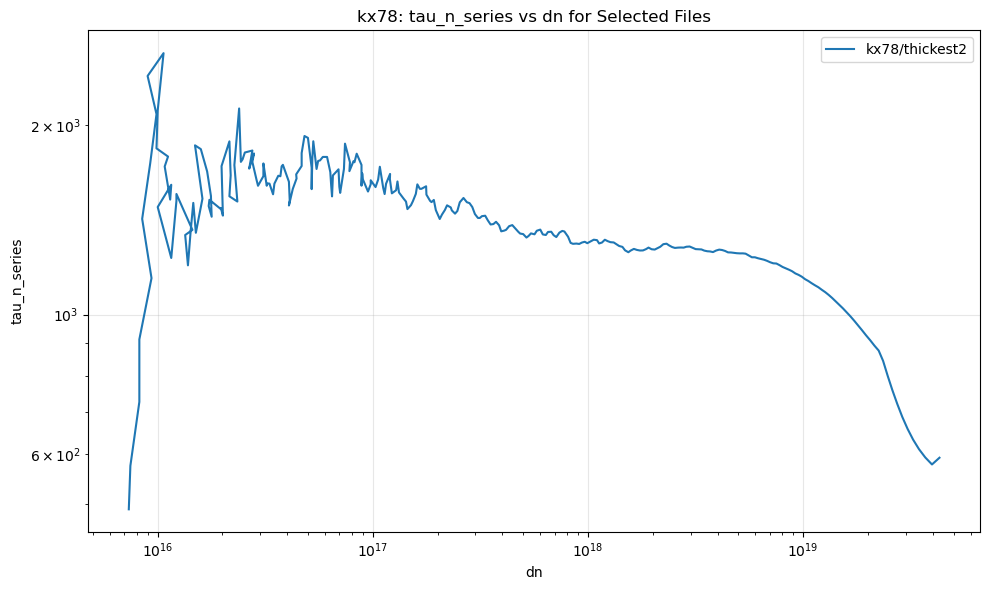

In [98]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
plt.figure(figsize=(10,6))
for key in [
    'kx78/thickest2',
    # 'kx78/thickest3',
    # 'kx78/thickest4',
    # 'kx78/thickest1/150.trn'
]:
    if key in results:
        plt.loglog(results[key]['delta_n'], results[key]['tau_n_series'], label=key)
        # plt.yscale('log')
    else:
        print(f'Missing: {key}')
plt.xlabel('dn')
plt.ylabel('tau_n_series')
plt.title('kx78: tau_n_series vs dn for Selected Files')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

all plots

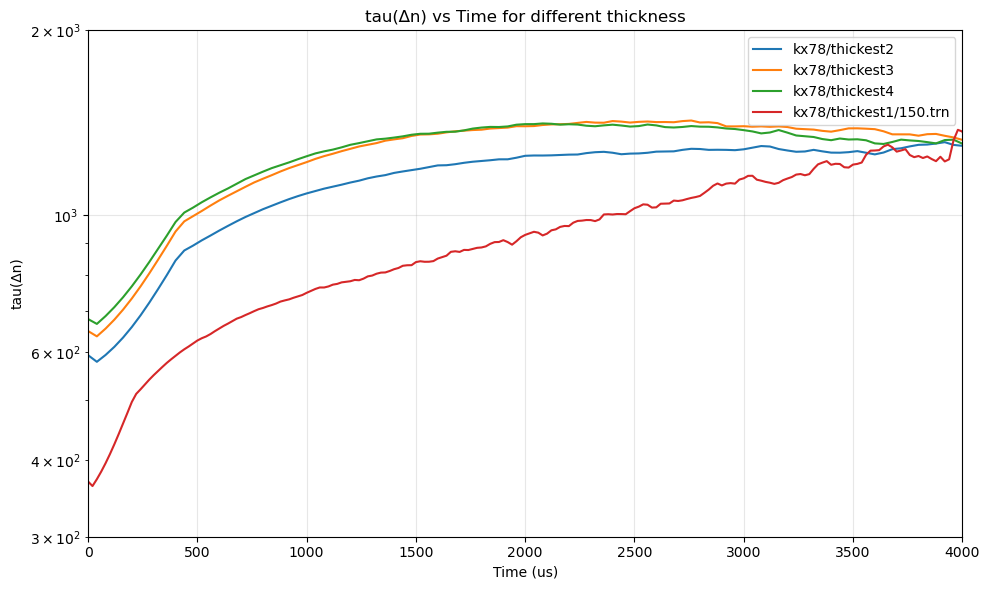

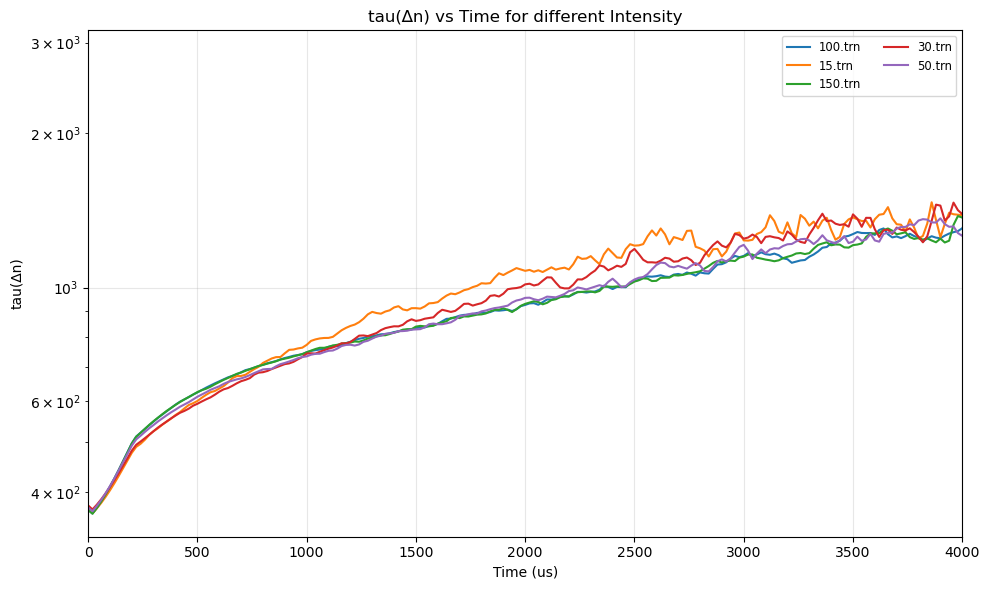

In [99]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
plt.figure(figsize=(10,6))
for key in [
    'kx78/thickest2',
    'kx78/thickest3',
    'kx78/thickest4',
    'kx78/thickest1/150.trn'
]:
    if key in results:
        plt.plot(results[key]['times'], results[key]['tau_n_series'], label=key)
        plt.yscale('log')
    else:
        print(f'Missing: {key}')
plt.xlabel('Time (us)')
plt.ylabel('tau(∆n)')
plt.xlim([0,4000])
plt.ylim([3e2,2e3])
plt.title('tau(∆n) vs Time for different thickness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Second plot: all thickest1/*.trn files in kx78
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('kx78/thickest1/')]
for key in sorted(thick1_keys):
    plt.plot(results[key]['times'], results[key]['tau_n_series'], label=key.split('/')[-1])
    plt.yscale('log')
plt.xlabel('Time (us)')
plt.ylabel('tau(∆n)')
plt.xlim([0,4000])
# plt.ylim([3e2,2e3])
plt.title('tau(∆n) vs Time for different Intensity')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

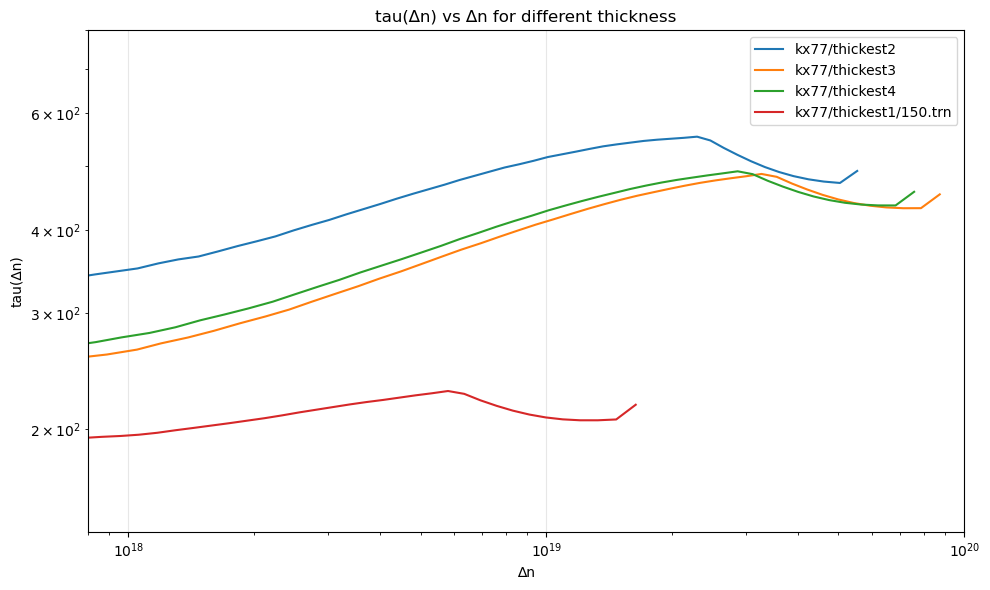

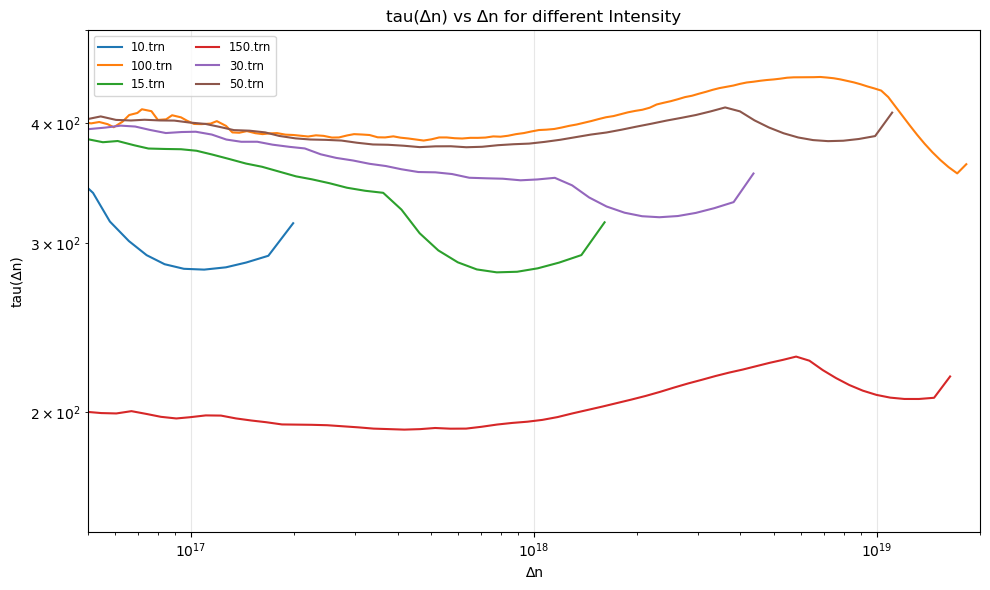

In [100]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
plt.figure(figsize=(10,6))
for key in [
    'kx77/thickest2',
    'kx77/thickest3',
    'kx77/thickest4',
    'kx77/thickest1/150.trn'
]:
    if key in results:
        plt.loglog(results[key]['delta_n'], results[key]['tau_n_series'], label=key)
        # plt.yscale('log')
    else:
        print(f'Missing: {key}')
plt.xlabel('∆n')
plt.ylabel('tau(∆n)')
plt.xlim([8e17,1e20])
plt.ylim([1.4e2,8e2])
plt.title('tau(∆n) vs ∆n for different thickness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Second plot: all thickest1/*.trn files in kx78
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('kx77/thickest1/')]
for key in sorted(thick1_keys):
    plt.loglog(results[key]['delta_n'], results[key]['tau_n_series'], label=key.split('/')[-1])
    # plt.yscale('log')
plt.xlabel('∆n')
plt.ylabel('tau(∆n)')
# plt.xlim([0,4000])
plt.xlim([5e16,2e19])
plt.ylim([1.5e2,5e2])
plt.title('tau(∆n) vs ∆n for different Intensity')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

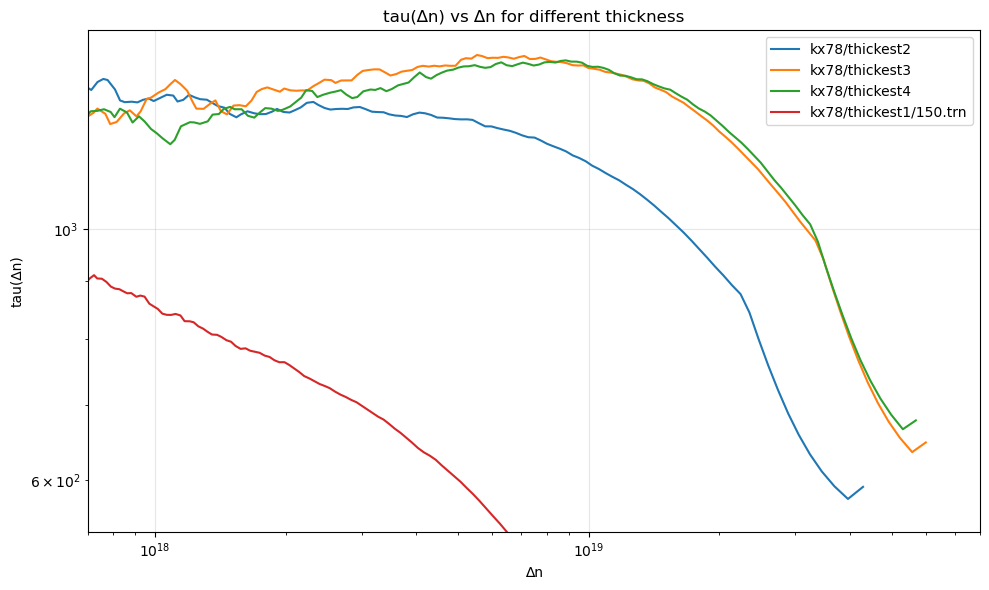

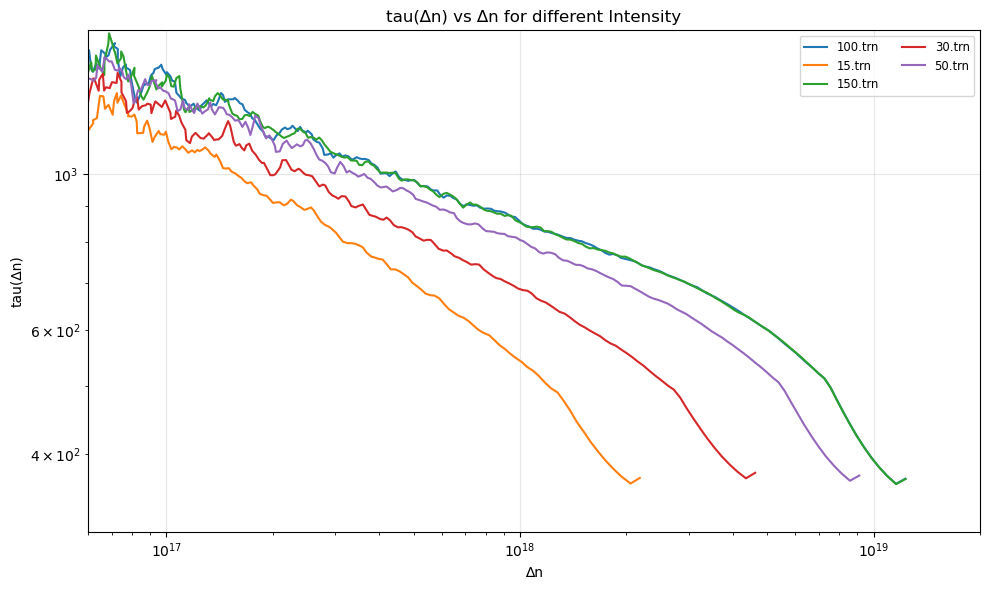

In [119]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# First plot: thickest2.trn, thickest3.trn, thickest4.trn, thickest1/150.trn
plt.figure(figsize=(10,6))
for key in [
    'kx78/thickest2',
    'kx78/thickest3',
    'kx78/thickest4',
    'kx78/thickest1/150.trn'
]:
    if key in results:
        plt.loglog(results[key]['delta_n'], results[key]['tau_n_series'], label=key)
        # plt.yscale('log')
    else:
        print(f'Missing: {key}')
plt.xlabel('∆n')
plt.ylabel('tau(∆n)')
plt.xlim([7e17,8e19])
plt.ylim([5.4e2,1.5e3])
plt.title('tau(∆n) vs ∆n for different thickness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Second plot: all thickest1/*.trn files in kx78
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('kx78/thickest1/')]
for key in sorted(thick1_keys):
    plt.loglog(results[key]['delta_n'], results[key]['tau_n_series'], label=key.split('/')[-1])
    # plt.yscale('log')
plt.xlabel('∆n')
plt.ylabel('tau(∆n)')
# plt.xlim([0,4000])
plt.xlim([6e16,2e19])
plt.ylim([3.1e2,1.6e3])
plt.title('tau(∆n) vs ∆n for different Intensity')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SECOND THIRD

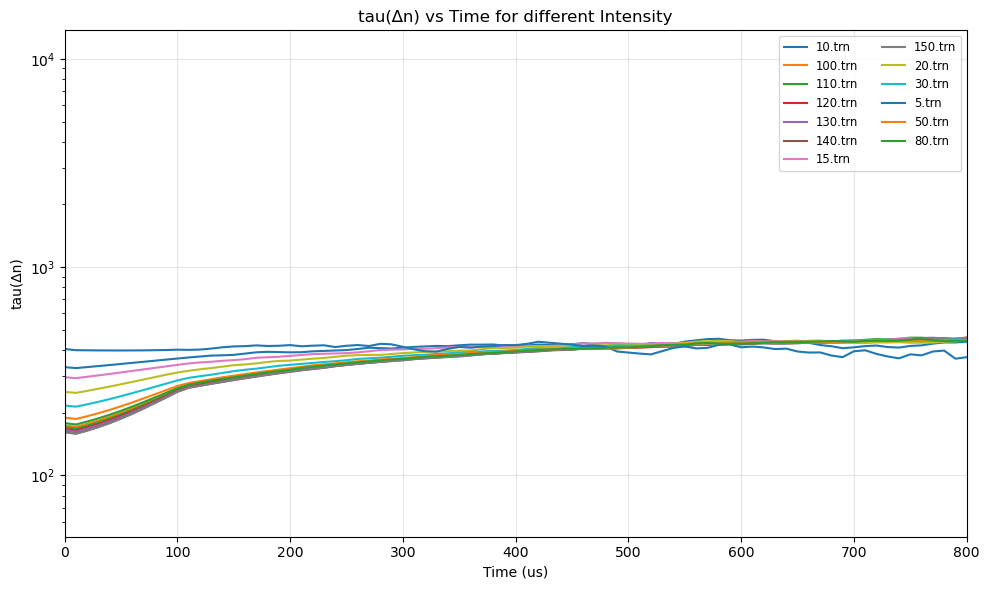

In [101]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# Second plot: all thickest1/*.trn files in kx78
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('second/')]
for key in sorted(thick1_keys):
    plt.plot(results[key]['times'], results[key]['tau_n_series'], label=key.split('/')[-1])
    plt.yscale('log')
plt.xlabel('Time (us)')
plt.ylabel('tau(∆n)')
plt.xlim([0,800])
plt.title('tau(∆n) vs Time for different Intensity')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

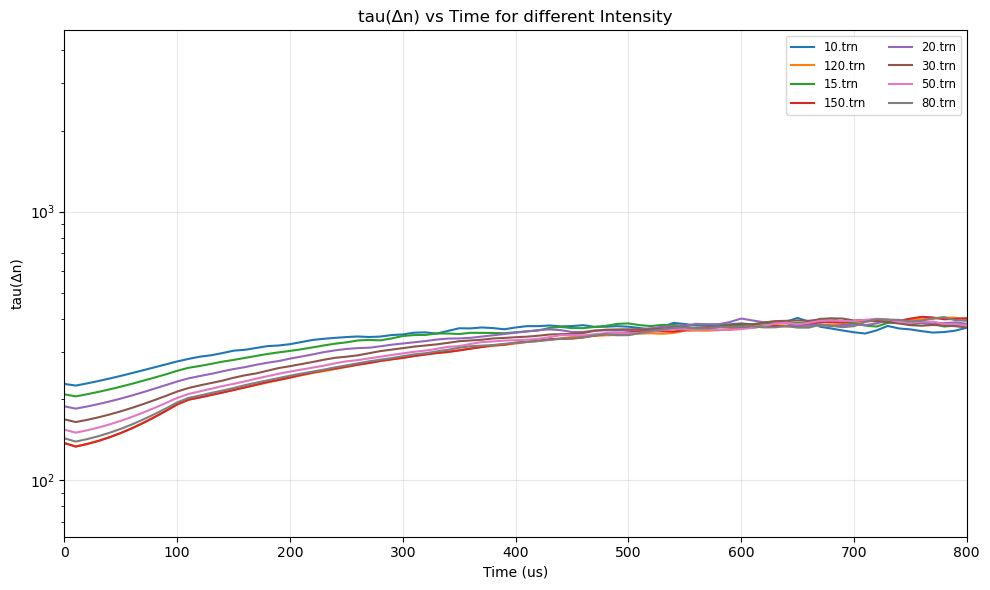

In [102]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# Second plot: all thickest1/*.trn files in kx78
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('third/')]
for key in sorted(thick1_keys):
    plt.plot(results[key]['times'], results[key]['tau_n_series'], label=key.split('/')[-1])
    plt.yscale('log')
plt.xlabel('Time (us)')
plt.ylabel('tau(∆n)')
plt.xlim([0,800])
plt.title('tau(∆n) vs Time for different Intensity')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

delta n tn

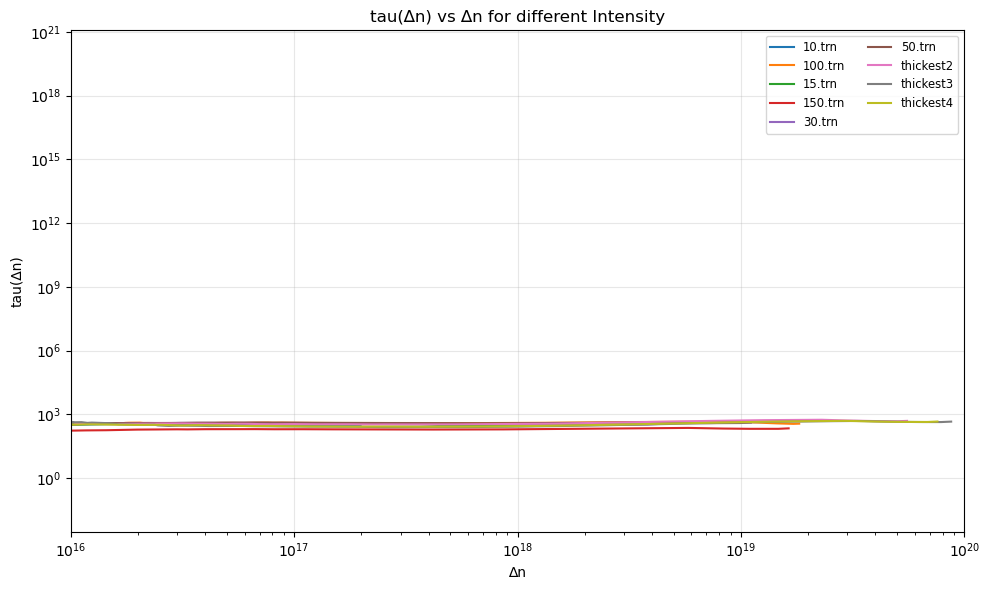

In [103]:
# Plot delta_n vs time for selected kx78 files
import matplotlib.pyplot as plt

# Second plot: all thickest1/*.trn files in kx78
plt.figure(figsize=(10,6))
thick1_keys = [k for k in results if k.startswith('kx77/')]
for key in sorted(thick1_keys):
    plt.loglog(results[key]['delta_n'], results[key]['tau_n_series'], label=key.split('/')[-1])
    # plt.yscale('log')
plt.xlabel('∆n')
plt.ylabel('tau(∆n)')
plt.xlim([1e16,1e20])
# plt.xlim([1e18,1e20])
plt.title('tau(∆n) vs ∆n for different Intensity')
plt.legend(ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Processing Wafer: kx77
Processing Wafer: kx78


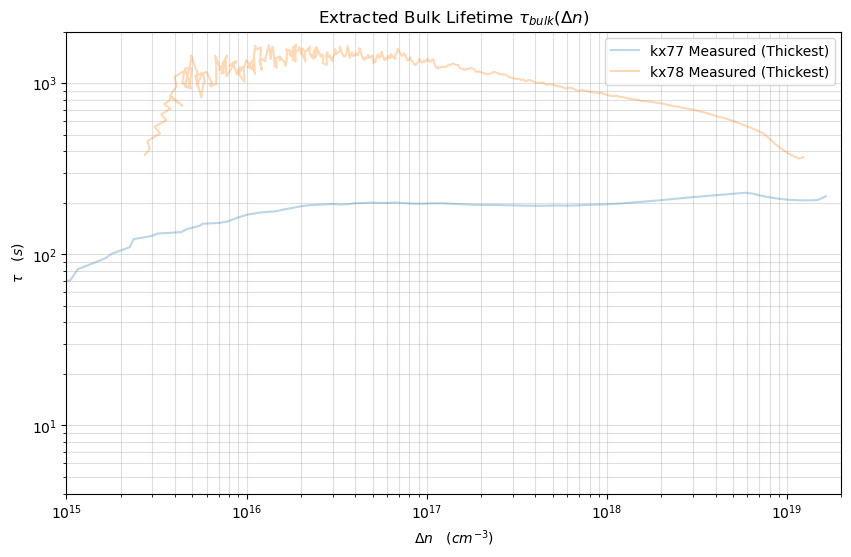

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def separate_bulk_surface(results, wafer_params, thickness_unit_mm=True):
    """
    Separates Bulk and Surface lifetimes by fitting 1/tau vs 1/W^2.
    
    Parameters:
    -----------
    results : dict
        Your dictionary containing 'delta_n' and 'tau_n_series' for each file.
    wafer_params : dict
        Dictionary defining thicknesses (e.g., {'kx78': {'thickest1': 2.40, ...}}).
    thickness_unit_mm : bool
        If True, treats dictionary thickness values as mm and converts to cm.
    
    Returns:
    --------
    bulk_results : dict
        Contains 'delta_n', 'tau_bulk', and 'tau_surf' curves for each wafer.
    """
    
    bulk_data = {}

    for wafer_name, params in wafer_params.items():
        print(f"Processing Wafer: {wafer_name}")
        
        # 1. Collect Curves for this Wafer
        # We need to match the params keys (thickest1, etc.) to your results keys
        thicknesses_cm = []
        tau_curves = []
        dn_curves = []
        
        for thick_key, thick_val in params.items():
            if thick_key in ['Ndop', 'V_background']: continue
            
            # Find the matching result key (e.g., 'kx78/thickest1/150.trn')
            # We look for a key in 'results' that contains both wafer_name and thick_key
            matched_key = None
            for res_key in results.keys():
                if wafer_name in res_key and thick_key in res_key:
                    matched_key = res_key
                    break
            
            if matched_key and 'tau_n_series' in results[matched_key]:
                # Convert thickness to cm (standard physics unit)
                w_cm = thick_val / 10.0 if thickness_unit_mm else thick_val
                
                thicknesses_cm.append(w_cm)
                tau_curves.append(results[matched_key]['tau_n_series'])
                dn_curves.append(results[matched_key]['delta_n'])
            else:
                print(f"  Warning: No result found for {wafer_name}/{thick_key}")

        if len(thicknesses_cm) < 2:
            print("  Not enough thickness variations for separation.")
            continue

        # 2. Define Common Delta_n Grid
        # We need to intersect the valid ranges of all curves
        min_dn = max([np.min(dn) for dn in dn_curves])
        max_dn = min([np.max(dn) for dn in dn_curves])
        
        # Create Log-spaced grid
        common_dn = np.logspace(np.log10(min_dn), np.log10(max_dn), 100)
        
        # 3. Interpolate Tau values onto Common Grid
        inv_tau_matrix = [] # Shape: (num_thicknesses, num_dn_points)
        
        for dn_orig, tau_orig in zip(dn_curves, tau_curves):
            # Sort to ensure monotonic for interpolation
            sort_idx = np.argsort(dn_orig)
            dn_sorted = dn_orig[sort_idx]
            tau_sorted = tau_orig[sort_idx]
            
            # Interpolate (linear in log-log usually best, but linear-linear is okay for dense points)
            f_interp = interp1d(dn_sorted, tau_sorted, bounds_error=False)
            tau_interp = f_interp(common_dn)
            inv_tau_matrix.append(1.0 / tau_interp)
            
        inv_tau_matrix = np.array(inv_tau_matrix)
        
        # 4. Perform Linear Fit (1/tau vs 1/W^2) for each Delta_n
        # X-axis: 1/W^2
        x_fit = 1.0 / (np.array(thicknesses_cm)**2)
        
        tau_bulk_series = []
        r_squared_series = []
        
        for i in range(len(common_dn)):
            y_fit = inv_tau_matrix[:, i]
            
            # Linear Regression: y = Slope*x + Intercept
            # Intercept = 1/tau_bulk
            coeffs = np.polyfit(x_fit, y_fit, 1)
            slope, intercept = coeffs
            
            # Calculate R^2
            p = np.poly1d(coeffs)
            y_pred = p(x_fit)
            ss_res = np.sum((y_fit - y_pred)**2)
            ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
            r2 = 1 - (ss_res / ss_tot)
            r_squared_series.append(r2)
            
            # Extract Bulk Lifetime
            # If intercept is negative (noise), cap it
            if intercept <= 0:
                tau_bulk = np.nan
            else:
                tau_bulk = 1.0 / intercept
            
            tau_bulk_series.append(tau_bulk)
            
        bulk_data[wafer_name] = {
            'delta_n': common_dn,
            'tau_bulk': np.array(tau_bulk_series),
            'r_sq': np.array(r_squared_series)
        }

    return bulk_data

# --- Usage ---
bulk_results = separate_bulk_surface(results, wafer_params)

# --- Plotting ---
plt.figure(figsize=(10,6))

for wafer, data in bulk_results.items():
    dn = data['delta_n']
    tau_bulk = data['tau_bulk']
    
    # Plot Bulk
    # plt.loglog(dn, tau_bulk, '--', linewidth=2, label=f'{wafer} Bulk (Extracted)')
    
    # Optional: Plot one measured curve for comparison
    # (Just to see the difference)
    plt.loglog(results[f'{wafer}/thickest1/150.trn']['delta_n'], 
               results[f'{wafer}/thickest1/150.trn']['tau_n_series'], 
               alpha=0.3, label=f'{wafer} Measured (Thickest)')

plt.xlabel(r'$\Delta n \quad (cm^{-3})$')
plt.xlim([1e15,2e19])
plt.ylim([4e0,2e3])
plt.ylabel(r'$\tau \quad (s)$')
plt.title(r'Extracted Bulk Lifetime $\tau_{bulk}(\Delta n)$')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

--- Processing kx77 ---
--- Processing kx78 ---


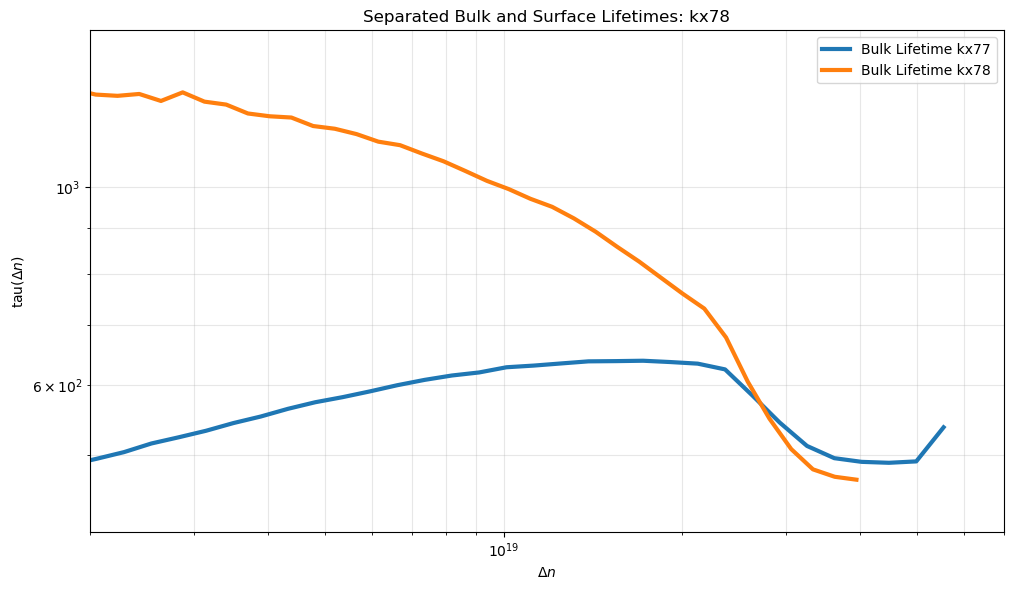

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def analyze_ingot_lifetimes(results, wafer_params):
    """
    Separates Bulk and Surface lifetimes for specific kx77 and kx78 files.
    Calculates tau_surface from the fitted slope (diffusion limited model).
    """
    
    # 1. Define the specific files we want to use (Exact matching)
    target_groups = {
        'kx77': [
            'kx77/thickest2', 
            'kx77/thickest3', 
            'kx77/thickest4', 
            # 'kx77/thickest1/150.trn'
        ],
        'kx78': [
            'kx78/thickest2', 
            'kx78/thickest3', 
            'kx78/thickest4', 
            # 'kx78/thickest1/150.trn'
        ]
    }

    # Storage for calculated curves
    output_data = {}

    for wafer_name, file_keys in target_groups.items():
        print(f"--- Processing {wafer_name} ---")
        
        # Get Thicknesses from params
        # We need to map the file key part (e.g. 'thickest2') to the param key
        # params example: {'thickest1': 2.52, ...}
        
        thicknesses_cm = []
        tau_curves = []
        dn_curves = []
        labels = []
        
        # Collect data for this wafer
        for file_key in file_keys:
            # 1. Find the corresponding result in your results dict
            # We search for the key that *contains* this string
            found_key = None
            for k in results.keys():
                if file_key in k:
                    found_key = k
                    break
            
            if found_key is None:
                print(f"  Missing data for: {file_key}")
                continue
                
            # 2. Determine Thickness
            # Extract 'thickestX' from the key to look up value
            thick_id = None
            if 'thickest1' in file_key: thick_id = 'thickest1'
            elif 'thickest2' in file_key: thick_id = 'thickest2'
            elif 'thickest3' in file_key: thick_id = 'thickest3'
            elif 'thickest4' in file_key: thick_id = 'thickest4'
            
            if thick_id and thick_id in wafer_params[wafer_name]:
                # Convert mm to cm
                t_cm = wafer_params[wafer_name][thick_id] / 10.0
                
                thicknesses_cm.append(t_cm)
                tau_curves.append(results[found_key]['tau_n_series'])
                dn_curves.append(results[found_key]['delta_n'])
                labels.append(thick_id)
            else:
                print(f"  Thickness not defined for {file_key}")

        if len(thicknesses_cm) < 2:
            print("  Not enough curves to fit.")
            continue

        # --- Perform Separation ---
        
        # 1. Common Grid
        min_dn = max([np.min(d) for d in dn_curves])
        max_dn = min([np.max(d) for d in dn_curves])
        common_dn = np.logspace(np.log10(min_dn), np.log10(max_dn), 100)
        
        # 2. Interpolate
        inv_tau_matrix = []
        for dn, tau in zip(dn_curves, tau_curves):
            # Sort to ensure monotonic for interp
            idx = np.argsort(dn)
            # Interpolate 1/tau
            f = interp1d(dn[idx], 1.0/tau[idx], bounds_error=False)
            inv_tau_matrix.append(f(common_dn))
        
        inv_tau_matrix = np.array(inv_tau_matrix)
        x_fit = 1.0 / (np.array(thicknesses_cm)**2)
        
        tau_bulk_series = []
        tau_surf_series_per_thick = {t: [] for t in thicknesses_cm}
        
        # 3. Fit per Delta_n point
        for i in range(len(common_dn)):
            y_fit = inv_tau_matrix[:, i]
            
            # Fit: y = mx + c
            # c = 1/tau_bulk
            # mx = 1/tau_surf
            coeffs = np.polyfit(x_fit, y_fit, 1)
            slope, intercept = coeffs
            
            # Bulk
            if intercept <= 1e-6: tau_b = np.nan # Avoid noise/negatives
            else: tau_b = 1.0 / intercept
            tau_bulk_series.append(tau_b)
            
            # Surface (for each thickness)
            # tau_surf = 1 / (slope * (1/W^2)) = W^2 / slope
            for w in thicknesses_cm:
                if slope <= 1e-9: tau_s = np.nan
                else: tau_s = (w**2) / slope
                tau_surf_series_per_thick[w].append(tau_s)

        output_data[wafer_name] = {
            'dn': common_dn,
            'tau_bulk': np.array(tau_bulk_series),
            'tau_surf_dict': tau_surf_series_per_thick,
            'thicknesses': thicknesses_cm,
            'labels': labels
        }
        
    return output_data

# --- Usage ---
data_sep = analyze_ingot_lifetimes(results, wafer_params)
plt.figure(figsize=(10, 6))

# --- Plotting ---
for wafer, dat in data_sep.items():
    
    # 1. Plot Bulk
    plt.loglog(dat['dn'], dat['tau_bulk'], linewidth=3, label=f'Bulk Lifetime {wafer}')
    
    # 2. Plot Surface (for each thickness)
    # Using dashed lines to distinguish
    colors = plt.cm.viridis(np.linspace(0, 1, len(dat['thicknesses'])))
    # for (w, curve), color, lbl in zip(dat['tau_surf_dict'].items(), colors, dat['labels']):
    #     w_mm = w * 10
    #     plt.loglog(dat['dn'], curve, '--', color=color, 
    #                label=f'Surface Term ({lbl}, {w_mm}mm)')
        
plt.xlabel('$\Delta n$')
plt.ylabel('tau($\Delta n$)')
plt.title(f'Separated Bulk and Surface Lifetimes: {wafer}')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.xlim([2e18,7e19])
plt.ylim([4.1e2,1.5e3])
plt.show()

--- Fit Visualization for kx78 ---


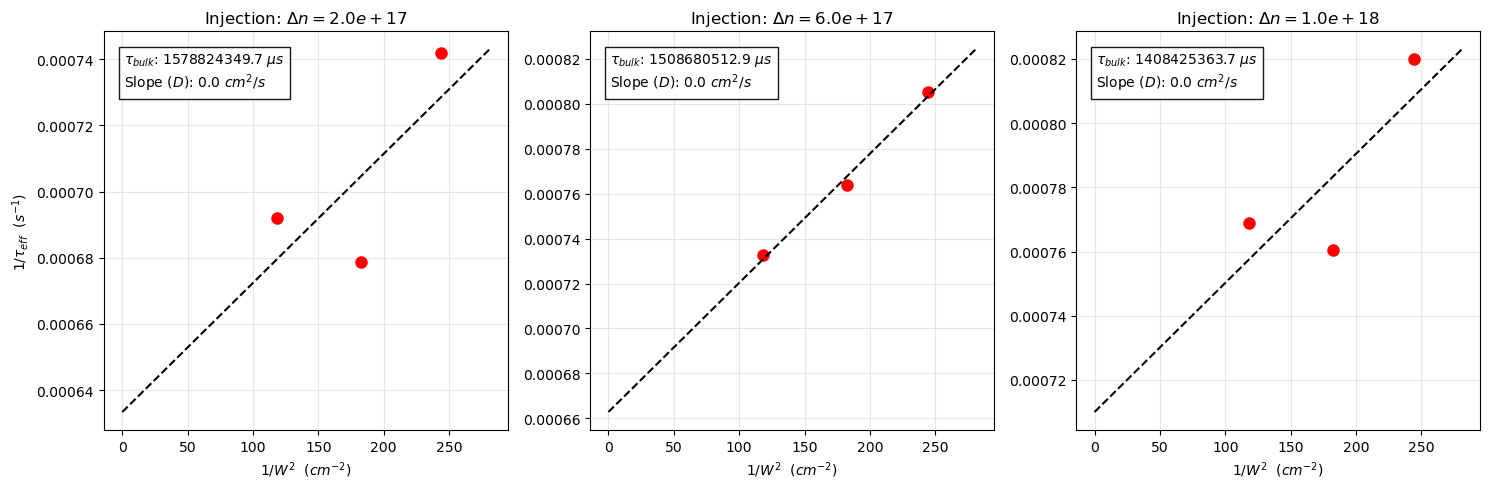

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def visualize_separation_fits(results, wafer_params, wafer_name, dn_levels):
    """
    Plots the linear regression (1/tau vs 1/W^2) for specific injection levels.
    Useful for verifying the quality of the Bulk/Surface separation.
    
    Parameters:
    -----------
    results : dict
        Your data dictionary.
    wafer_params : dict
        Your wafer parameters.
    wafer_name : str
        'kx77' or 'kx78'
    dn_levels : list
        List of Delta_n values to check (e.g. [1e17, 5e17, 1e18])
    """
    
    # Define the specific files (Same as your analysis code)
    # target_groups = {
    #     'kx77': ['kx77/thickest2', 'kx77/thickest3', 'kx77/thickest4', 'kx77/thickest1/150.trn'],
    #     'kx78': ['kx78/thickest2', 'kx78/thickest3', 'kx78/thickest4', 'kx78/thickest1/150.trn']
    # }
    target_groups = {
        'kx77': ['kx77/thickest2', 'kx77/thickest3', 'kx77/thickest4'],
        'kx78': ['kx78/thickest2', 'kx78/thickest3', 'kx78/thickest4']
    }
    
    files_to_use = target_groups.get(wafer_name)
    if not files_to_use:
        print(f"No file definition found for {wafer_name}")
        return

    # 1. Collect Data Points (W and tau) for this wafer
    thicknesses_cm = []
    tau_curves = []
    dn_curves = []
    
    for file_key in files_to_use:
        # Find matching key in results
        match = next((k for k in results.keys() if file_key in k), None)
        
        if match:
            # Determine Thickness from key string
            thick_id = None
            for i in range(1, 5):
                if f'thickest{i}' in file_key: 
                    thick_id = f'thickest{i}'
                    break
            
            if thick_id:
                w_cm = wafer_params[wafer_name][thick_id] / 10.0 # mm to cm
                thicknesses_cm.append(w_cm)
                tau_curves.append(results[match]['tau_n_series'])
                dn_curves.append(results[match]['delta_n'])
    
    thicknesses_cm = np.array(thicknesses_cm)
    x_axis = 1.0 / (thicknesses_cm**2) # X = 1/W^2

    # 2. Setup Plot
    num_plots = len(dn_levels)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5), sharey=False)
    if num_plots == 1: axes = [axes]
    
    print(f"--- Fit Visualization for {wafer_name} ---")

    # 3. Process each Delta_n level
    for ax, target_dn in zip(axes, dn_levels):
        
        y_points_inv_tau = []
        
        # Interpolate 1/tau for each thickness at this specific Delta_n
        for dn_arr, tau_arr in zip(dn_curves, tau_curves):
            # Sort for interpolation
            idx = np.argsort(dn_arr)
            # Interpolate
            val = interp1d(dn_arr[idx], 1.0/tau_arr[idx], bounds_error=False)(target_dn)
            y_points_inv_tau.append(val)
            
        y_points_inv_tau = np.array(y_points_inv_tau)
        
        # Filter valid points (remove NaNs from interpolation bounds)
        valid = ~np.isnan(y_points_inv_tau)
        
        if np.sum(valid) < 2:
            ax.set_title(f"$\Delta n = {target_dn:.1e}$: No Data")
            continue
            
        # Linear Fit: Y = Slope * X + Intercept
        x_valid = x_axis[valid]
        y_valid = y_points_inv_tau[valid]
        
        coeffs = np.polyfit(x_valid, y_valid, 1)
        slope, intercept = coeffs
        
        # Calculate Physical Values
        tau_bulk = 1.0 / intercept if intercept > 0 else np.nan
        # tau_surf = W^2 / (pi^2 * D) -> Slope = pi^2 * D
        diff_coeff = slope / (np.pi**2)
        
        # Plotting
        # 1. Data Points
        ax.plot(x_valid, y_valid, 'ro', markersize=8, label='Meas.')
        
        # 2. Fit Line
        x_line = np.linspace(0, max(x_valid)*1.15, 10)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'k--', label='Linear Fit')
        
        # Labels and Style
        ax.set_xlabel(r'$1/W^2$  ($cm^{-2}$)')
        ax.set_title(f'Injection: $\Delta n = {target_dn:.1e}$')
        
        # Only label Y-axis on the first plot to save space
        if ax == axes[0]:
            ax.set_ylabel(r'$1/\tau_{eff}$  ($s^{-1}$)')
            
        # Annotation Box
        stats = (f"$\\tau_{{bulk}}$: {tau_bulk*1e6:.1f} $\mu s$\n"
                 f"Slope ($D$): {diff_coeff:.1f} $cm^2/s$")
        ax.text(0.05, 0.95, stats, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
        
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Run this block to see the fits ---
# Pick 3 injection levels that are actually inside your data range (check your previous loglog plots)
# Based on your previous xlim, 1e17 to 1e18 seems safe.
visualize_separation_fits(results, wafer_params, 'kx78', dn_levels=[2e17, 6e17, 1e18])

(4.0, 2000.0)

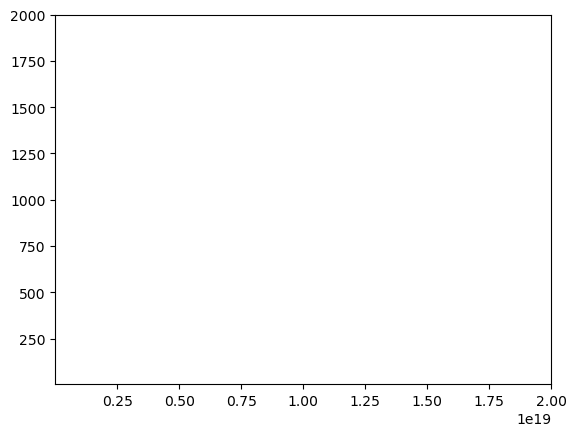

In [107]:
plt.xlim([1e15,2e19])
plt.ylim([4e0,2e3])

dn(time) in semilog plot should look kinda linear because it is exponential decay with a slightly changing exponent

using the delta sigma method

In [108]:
# new with delta_sigma

# # Constants
# q = 1.60217663e-19  # Electron charge [C]

# def calculate_transient_delta_n(
#     sigma_s_series, 
#     W, 
#     Ndop, 
#     dopant_species='B', 
#     T=300.0, 
#     sigma_s_background=None, # New optional parameter
#     tolerance=1e-3, 
#     max_iter=20
# ):
#     """
#     Iteratively calculates the excess carrier concentration Delta_n(t).
    
#     If 'sigma_s_background' is provided, it calculates excess carriers relative 
#     to that measured baseline. Otherwise, it calculates the theoretical background 
#     conductivity using Ndop and mobility.

#     Parameters:
#     -----------
#     sigma_s_series : array-like
#         Time-series of total sheet conductance [S].
#     W : float
#         Wafer thickness [cm].
#     Ndop : float
#         Doping concentration [cm^-3].
#     dopant_species : str
#         'P' (n-type) or 'B' (p-type).
#     T : float
#         Temperature [K].
#     sigma_s_background : float, optional
#         Measured equilibrium sheet conductance [S]. If provided, calculating 
#         Delta_n uses (sigma_s - sigma_s_background).
#     """
    
#     sigma_s_series = np.array(sigma_s_series)
#     delta_n_series = np.zeros_like(sigma_s_series, dtype=float)
#     delta_n_converged = np.zeros_like(sigma_s_series, dtype=float)
    
#     # Initial guess for Delta_n
#     current_dn_guess = 1.0e14 

#     for i, sigma_s in enumerate(sigma_s_series):
        
#         for iteration in range(max_iter):
            
#             # 1. Get Mobilities based on current guess of Delta_n
#             # (Requires the calculate_mobility_and_properties function defined previously)
#             props = calculate_mobility_and_properties(
#                 material='c-Si',
#                 dopant_species=dopant_species,
#                 Ndop=Ndop,
#                 Delta_n=current_dn_guess,
#                 Delta_p=current_dn_guess,
#                 T=T,
#                 tau_eff_e=1e-6, 
#                 tau_eff_h=1e-6
#             )
            
#             mu_e = props['mu_e']
#             mu_h = props['mu_h']
#             mu_sum = mu_e + mu_h
            
#             # 2. Calculate new Delta_n
#             if sigma_s_background is not None:
#                 # --- User Requested Method ---
#                 # Uses the measured background conductance directly
#                 delta_n_new = (sigma_s - sigma_s_background) / (q * mu_sum * W)
                
#             else:
#                 # --- Theoretical Method ---
#                 # Calculates background conductivity from doping and majority mobility
#                 if dopant_species == 'P': # n-type
#                     mu_maj = mu_e
#                 else: # p-type
#                     mu_maj = mu_h
                
#                 conductivity_total = sigma_s / W
#                 conductivity_background = q * Ndop * mu_maj
                
#                 delta_n_new = (conductivity_total - conductivity_background) / (q * mu_sum)
            
#             # 3. Sanity Check (prevent negative/zero logs or physical impossibilities)
#             if delta_n_new < 1e10:
#                 delta_n_new = 1e10
                
#             # 4. Check Convergence
#             if current_dn_guess > 0:
#                 rel_error = abs(delta_n_new - current_dn_guess) / current_dn_guess
#             else:
#                 rel_error = 1.0
                
#             current_dn_guess = delta_n_new
            
#             if rel_error < tolerance:
#                 delta_n_converged[i] = 1
#                 # print(":)")
#                 break
        
#         delta_n_series[i] = current_dn_guess

#     return delta_n_series, delta_n_converged